# EPANET simulation experiments (v2) — E0 reproduction, E0c time step, E4 dose–response, E2 mediator blocking

**Why.** The dependence labels rest on interventional gains measured in the study's worlds. Three questions need
new simulations: does re-simulation reproduce the stored worlds (**E0**, a gate for everything else)? Is the response
linear in the dose, and does the study's evidence agree with an exact, noise-free response (**E4**, U3 and U6)?
How much of a response goes through storage — pumps, controlled valves, tanks — and does the switch fit get it right
(**E2**, U2)? **E0c** answers whether hourly snapshots, or the 1 h hydraulic step itself, distort what is stored.

| exp. | runs | truth it provides |
|---|---|---|
| **E0** | every world, init window, through `run_hydraulics` and through the EPANET toolkit step loop | re-run = stored; snapshot vs hour-average flows; tank volume closure |
| **E0c** | one world per partition, 3 months, hydraulic step 3600 / 900 / 300 s | whether the 1 h step changes the solution or the gains |
| **E4** | one world per partition, 3 months from hour 0; one district's demand × (1+δ) from month 1 | exact paired gains per link, linearity, pump drives, saturation |
| **E2** | E4's ±20 % runs, with every mediator held on a recorded trajectory | the exact demand / storage split, its interaction, and a test of $\sum_p b\gamma$ |

**Model.** Rebuilt as the pipeline builds it (read-only engine code): bundle `.inp` → `configure_network` (solver
1e-5 / 200 / STOP, units, 1 h steps) → `apply_coupling` → demand injected with `run_hydraulics`' convention
(1 L/s base × pattern = series). Every run starts at hour 0: tanks settle within the first month, and the network's
own patterns (weekly D-Town, KY7 pump/energy) are aligned to hour 0. **Pairing:** a dosed run and its baseline see
the same demand except district $k$'s, so their difference is the response — deterministic, no null needed.

**Not tested here.** Uniform scaling keeps $k$'s demand shape, so no shape-space gain exists in E4/E2 (the study's
drift changes shape and the spatial pattern within $k$). E2 is read on snapshots only: a blocked network holds no
tanks, so each hour is an independent steady state and its hour average equals its snapshot.

**Changes from v1.** Every run is checked for completion and convergence (G-run gates): an unconverged step under
`UNBALANCED STOP` halts EPANET silently, which v1 did not detect. Minimum pressure is taken over junctions that carry
demand (KY7's pump suction sits at −8.6 m by design). E0c compares the two finer steps directly. Doses ±40 % are
dropped; linearity is read as $g(-20\%)$ vs $g(+20\%)$ and $g(+5\%)$ vs $g(+20\%)$. E2's twin imposes pump speeds,
checks every hour for a head reference, and saves hour-by-hour reproduction errors and the mediators it holds.

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib, json, datetime, time, copy, ctypes, tempfile
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.stats import mannwhitneyu, spearmanr

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
import wntr
from wntr.epanet import toolkit
from wntr.network.io import write_inpfile
from wntr.network.controls import Control, ControlAction
from fedwater.pipelines.network_prep.nodes import configure_network, apply_coupling     # read-only
from fedwater.pipelines.hydraulics.nodes import run_hydraulics, scratch_root, _remove, UNIT_BASE_SI
from fedwater.placement import signal_probe as sp
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 300)
plt.rcParams.update({"figure.dpi": 90, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = "ky72_districting_all_districts"                    # set explicitly per network
ATLAS = Atlas(root=EXPERIMENTS)
WORLDS = ATLAS.worlds(STUDY, ok_only=True).reset_index(drop=True)
BASE = REPO / "notebooks" / "outputs" / STUDY
OUT = BASE / "epanet_sim"
OUT.mkdir(parents=True, exist_ok=True)

# which sections run (E0 gates everything after it)
RUN_E0, RUN_E0C, RUN_E4, RUN_E2 = True, False, True, True
E0_TOOLKIT = True                # toolkit pass on every world's init window (snapshot vs average, tank closure)

# design
H_MONTHS = 3                     # horizon of every E0c / E4 / E2 run, from hour 0
STEP_MONTH = 1                   # the dose starts at the beginning of this month (month 0 = tank warm-up)
SETTLE_DAYS = 7                  # analysis window starts this long after the step
DOSES = [-0.20, -0.05, 0.05, 0.20]          # ±40 % dropped: negative pressures on D-Town, no added information
E2_DOSES = [-0.20, 0.20]
MODES = ["M1", "M2"]             # M1 tanks -> fixed-head reservoirs; M2 tanks -> fixed-flow junctions
FINE_STEPS = [900, 300]          # E0c hydraulic timesteps (s) compared with the pipeline's 3600 and with each other
E0C_DOSE = 0.20                  # E0c: gains at 3600 s vs FINE_STEPS[0], this dose, every district

# gates
GATE_E0_REL = 1e-6               # re-run vs stored flows, max |dq| / max |q| per link (stored output is float32)
GATE_E0_LEVEL = 1e-4             # re-run vs stored tank levels, m
GATE_E0_CLOSURE = 1e-4           # tank volume closure with hour-averaged flows, max |res| / gross |dV|
GATE_E4_BRANCH = 1e-3            # |g - g_exact| on branch links (gain units)
GATE_E2_REL = 5e-4               # blocked twin vs the run it copies, max |dq| / mean |q| (links above the flow floor)
GATE_E2_BRANCH = 1e-3            # indirect (storage) gain on branch links
PMIN_DROP = 0.5                  # m: a dose is flagged if its minimum consumer pressure goes below zero (or, where the
                                 # baseline is already below zero, falls this much further)
FLOW_FLOOR = 1e-3                # links with mean |q| below this x median are excluded from relative gates (L/s ratio)
EPS_RESP = [1e-3, 3e-3, 1e-2]    # |g| above which an E4 response counts as non-zero
EPS_MIN = 1e-3                   # minimum |g_tot| for relative channel comparisons
VALVE_OPEN_SETTING = 1e8         # EPANET reports no setting (a huge value) for a valve fixed open
LEVEL_TOL = 1e-3                 # m: a tank within this of its min / max level is at a limit

DW = pd.read_parquet(BASE / "dependence" / "worlds.parquet")                 # init windows (i0, i1) per world
TOPO = pd.read_parquet(BASE / "dependence" / "topology.parquet")
LBf = pd.read_parquet(BASE / "dependence" / "labels.parquet")
SE = pd.read_parquet(BASE / "dependence_analysis" / "sensor_evidence.parquet")
SWB = pd.read_parquet(BASE / "dependence" / "switch_b.parquet")
print(f"study {STUDY}: {len(WORLDS)} ok worlds  ->  {OUT}")

study ky72_districting_all_districts: 12 ok worlds  ->  c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\outputs\ky72_districting_all_districts\epanet_sim


### Harness

`simulate` runs EPANET 2.2 through the toolkit loop (`ENrunH` / `ENnextH`), the same solve `EpanetSimulator` performs,
visiting every intermediate step (EPANET adds steps when a control fires or a tank reaches a limit inside the hour).
Per hour $h$:

| output | definition |
|---|---|
| `snap` | $q(t_h)$, the flow at the hour — what the stored worlds hold (report step = hydraulic step = 1 h) |
| `avg` | $\bar q_h=\frac1{3600}\sum_{i\in h} q_i\,\Delta t_i$ over the solver's steps $i$ in $[t_h,t_h+1\,\text{h})$ |
| `on_frac` | pumps' open fraction over the hour; `med_status` / `med_setting` mediators at $t_h$ |
| `tank_head`, `tank_vol` | at $t_h$; `pmin` minimum junction pressure at $t_h$ |

**Mediators** = every pump plus every link a control acts on. **Blocked twin** (`blocked_model`): all controls
removed; each mediator follows a recorded trajectory as hourly time controls (closed / open / active with setting);
each tank replaced by **M1** a reservoir whose head follows the trajectory (pipes EPANET had closed while the tank sat
at a level limit stay closed), or **M2** a junction whose demand is the tank's recorded net inflow.

In [2]:
EN_ELEV, EN_HEAD, EN_PRESSURE, EN_TANKVOL = 0, 10, 11, 24     # EPANET 2.2 node codes
EN_FLOW, EN_STATUS, EN_SETTING = 8, 11, 12                       # EPANET 2.2 link codes


def build_model(w):
    """The world's simulation model, rebuilt the way the pipeline builds it (network_prep, read-only):
    raw bundle .inp -> configure_network (solver, units, time) -> apply_coupling. Demand is injected later."""
    wn = copy.deepcopy(w.network_model)
    wn, _ = configure_network(wn, {"name": w.row["network"]}, w.params["hydraulics"], w.params["time"])
    wn, _ = apply_coupling(wn, w.catalog.load("districts"), w.params["coupling"], w.params["seed"])
    return wn


def set_horizon(wn, hours, hyd_step=3600):
    # duration only; pattern and report steps stay as configure_network pinned them (1 h)
    wn.options.time.duration = int(hours) * 3600
    wn.options.time.hydraulic_timestep = int(hyd_step)
    return wn


def inject_demand(wn, demand):
    """Verbatim convention of run_hydraulics: base 1 L/s, pattern = the series in L/s; junctions without a
    column are pinned to zero."""
    cols = [c for c in demand.columns if c != "month"]
    for node in cols:
        j = wn.get_node(node)
        wn.add_pattern(f"P{node}", demand[node].to_list())
        j.demand_timeseries_list[0].base_value = UNIT_BASE_SI
        j.demand_timeseries_list[0].pattern_name = f"P{node}"
    for node in set(wn.junction_name_list) - set(cols):
        slot = wn.get_node(node).demand_timeseries_list[0]
        slot.base_value, slot.pattern_name = 0.0, None
    return wn


def mediators(wn):
    # every pump, and every link a control acts on (pumps, level-controlled valves and pipes)
    out = set(wn.pump_name_list)
    for _, c in wn.controls():
        for a in c.actions():
            obj, attr = a.target()
            if attr in ("status", "setting") and getattr(obj, "name", None) in wn.link_name_list:
                out.add(obj.name)
    return sorted(out)


def simulate(wn, demand, hours, hyd_step=3600, pmin_nodes=None, dtype=np.float64):
    """EPANET 2.2 run through the toolkit step loop: every intermediate step of the solve is visited, the
    solution is the one EpanetSimulator computes. Returns, per hour h (t = 3600 h):
      snap   flows at t (what the stored data hold), L/s        avg  time-average over [t, t+1h), L/s
      med_status / med_setting  mediator links at t             on_frac  pumps' time-average open fraction
      tank_head, tank_vol at t; pmin = min pressure at t over pmin_nodes (default: junctions that carry demand —
      a zero-demand node such as a pump suction can sit below zero by design); switches per pump over all steps.
    Every run reports `completed` (the solve reached the horizon) and the EPANET warning codes it met
    (`warnings`: code -> number of solver steps; 1 = unbalanced/unconverged, 2 = disconnected nodes,
    3/4/5 = pumps/valves cannot deliver, 6 = negative pressures). An unconverged step under UNBALANCED STOP
    halts EPANET silently: hours after the halt would read zero, so `completed` must be checked."""
    wn = inject_demand(set_horizon(copy.deepcopy(wn), hours, hyd_step), demand.iloc[:hours])
    links, tanks, pumps = list(wn.link_name_list), list(wn.tank_name_list), list(wn.pump_name_list)
    meds = mediators(wn)
    if pmin_nodes is None:
        dcols = [c for c in demand.columns if c != "month"]
        pmin_nodes = [c for c in dcols if float(np.abs(demand[c].iloc[:hours]).max()) > 0]
    juncs = [j for j in pmin_nodes if j in set(wn.junction_name_list)] or list(wn.junction_name_list)
    d = Path(tempfile.mkdtemp(prefix="fedwater_e024_", dir=scratch_root()))
    t0 = time.time()
    try:
        inp = str(d / "run.inp")
        write_inpfile(wn, inp, units=wn.options.hydraulic.inpfile_units, version=2.2)
        en = toolkit.ENepanet(version=2.2)
        en.ENopen(inp, str(d / "run.rpt"), str(d / "run.bin"))
        li = [en.ENgetlinkindex(x) for x in links]
        pi = [en.ENgetlinkindex(x) for x in pumps]
        mi = [en.ENgetlinkindex(x) for x in meds]
        ti = [en.ENgetnodeindex(x) for x in tanks]
        ji = [en.ENgetnodeindex(x) for x in juncs]
        lib, prj, val = en.ENlib, en._project, ctypes.c_double()
        get_l, get_n = lib.EN_getlinkvalue, lib.EN_getnodevalue

        def lv(idx, code):
            out = np.empty(len(idx))
            for j, i in enumerate(idx):
                get_l(prj, i, code, ctypes.byref(val)); out[j] = val.value
            return out

        def nv(idx, code):
            out = np.empty(len(idx))
            for j, i in enumerate(idx):
                get_n(prj, i, code, ctypes.byref(val)); out[j] = val.value
            return out

        L, P, M, T = len(links), len(pumps), len(meds), len(tanks)
        snap, avg = np.zeros((hours, L), dtype), np.zeros((hours, L), dtype)
        acc, acc_h = np.zeros(L), 0                              # float64 accumulator of the current hour
        warn, t_end = Counter(), 0
        run_h, next_h = lib.EN_runH, lib.EN_nextH
        lT, lS = ctypes.c_long(), ctypes.c_long()
        on_frac, mstat, mset = np.zeros((hours, P)), np.zeros((hours, M)), np.zeros((hours, M))
        thead, tvol, pmin = np.zeros((hours, T)), np.zeros((hours + 1, T)), np.zeros(hours)
        switches, last, n_steps = np.zeros(P), None, 0
        en.ENopenH(); en.ENinitH(0)
        while True:
            code = run_h(prj, ctypes.byref(lT))
            if code >= 100:
                raise RuntimeError(f"EPANET error {code} at t = {lT.value} s")
            if code:
                warn[int(code)] += 1
            t = int(lT.value)
            t_end = t
            q = lv(li, EN_FLOW)
            st = lv(pi, EN_STATUS) if P else np.zeros(0)
            h = t // 3600
            if t % 3600 == 0 and h <= hours:
                if T:
                    tvol[h] = nv(ti, EN_TANKVOL)
                if h < hours:
                    snap[h] = q
                    if M:
                        mstat[h], mset[h] = lv(mi, EN_STATUS), lv(mi, EN_SETTING)
                    if T:
                        thead[h] = nv(ti, EN_HEAD)
                    pmin[h] = nv(ji, EN_PRESSURE).min()
            if last is not None:
                switches += st != last
            last = st
            code = next_h(prj, ctypes.byref(lS))
            if code >= 100:
                raise RuntimeError(f"EPANET error {code} after t = {t} s")
            dt = int(lS.value)
            if h < hours and dt > 0:
                if h != acc_h:
                    avg[acc_h] = acc / 3600.0
                    acc, acc_h = np.zeros(L), h
                acc += q * dt
                on_frac[h] += st * dt
            n_steps += 1
            if dt <= 0:
                break
        if acc_h < hours:
            avg[acc_h] = acc / 3600.0
        en.ENcloseH(); en.ENclose()
    finally:
        _remove(d)
    return {"links": links, "pumps": pumps, "meds": meds, "tanks": tanks, "snap": snap, "avg": avg,
            "completed": t_end >= hours * 3600, "t_end_h": t_end / 3600.0, "warnings": dict(warn),
            "on_frac": on_frac / 3600.0, "med_status": mstat, "med_setting": mset, "tank_head": thead,
            "tank_vol": tvol, "pmin": pmin, "switches": switches, "n_steps": n_steps,
            "seconds": time.time() - t0}


def tank_inflow(wn, flows, links):
    # net inflow (L/s) of every tank from its incident links' flows (.inp orientation)
    ix = {l: i for i, l in enumerate(links)}
    out = {}
    for t in wn.tank_name_list:
        q = np.zeros(len(flows))
        for ln in wn.get_links_for_node(t):
            s = 1.0 if wn.get_link(ln).end_node_name == t else -1.0
            q += s * flows[:, ix[ln]]
        out[t] = q
    return out


def blocked_model(wn, demand, traj, mode, hours):
    """Mediator-blocked twin of a configured model. All controls are removed; every mediator link follows
    the trajectory `traj` (its status / setting at each hour, as hourly time controls); every tank is replaced:
      M1  by a reservoir whose head follows traj's tank head (fixed-head boundary); where the tank sat at a level
          limit, the incident pipes EPANET had closed stay closed
      M2  by a junction whose demand is traj's tank net inflow (fixed-flow boundary)
    Pumps follow their status and speed, valves their status and setting, controlled pipes their status.
    Without tanks the blocked network holds no state, so each hour is an independent steady state and the
    snapshot at hour h depends only on that hour's demand, boundary and statuses.
    Returns (model, demand frame with the M2 tank columns added, info: hours without a head reference)."""
    d = wntr.network.to_dict(wn)
    d["controls"] = []
    tq = tank_inflow(wn, traj["snap"], traj["links"])
    dem = demand.iloc[:hours].copy()
    nodes = []
    for nd in d["nodes"]:
        if nd["node_type"] != "Tank":
            nodes.append(nd); continue
        t, k = nd["name"], traj["tanks"].index(nd["name"])
        base = {"name": t, "coordinates": nd.get("coordinates")}
        if mode == "M1":
            pat = f"HEAD_{t}"
            d["patterns"].append({"name": pat, "multipliers": list(map(float, traj["tank_head"][:hours, k]))})
            nodes.append({**base, "node_type": "Reservoir", "base_head": 1.0, "head_pattern_name": pat})
        else:
            nodes.append({**base, "node_type": "Junction", "elevation": nd["elevation"],
                          "demand_timeseries_list": [{"base_val": 0.0, "pattern_name": None, "category": None}]})
            dem[t] = tq[t][:hours]
    d["nodes"] = nodes
    wb = wntr.network.from_dict(d)
    ix = {m: i for i, m in enumerate(traj["meds"])}
    LS = wntr.network.LinkStatus
    if mode == "M1":
        # a reservoir has no level limits: where the trajectory's tank sat full or empty, EPANET had closed the
        # tank's links that would overfill / overdraw it; those closures are part of the trajectory, so the
        # incident pipes that carried no flow at such hours are held closed there
        lix = {l: i for i, l in enumerate(traj["links"])}
        for k, t in enumerate(traj["tanks"]):
            tn = wn.get_node(t)
            hd = traj["tank_head"][:hours, k]
            at_lim = (hd >= tn.elevation + tn.max_level - LEVEL_TOL) | (hd <= tn.elevation + tn.min_level + LEVEL_TOL)
            for ln in wn.get_links_for_node(t):
                if ln in ix:
                    continue                                   # mediator links follow their own trajectory
                shut = at_lim & (np.abs(traj["snap"][:hours, lix[ln]]) < 1e-6)
                if not shut.any():
                    continue
                lk = wb.get_link(ln)
                if shut[0]:
                    lk.initial_status = LS.Closed
                for h in range(1, hours):
                    if shut[h] != shut[h - 1]:
                        act = ControlAction(lk, "status", LS.Closed if shut[h] else LS.Open)
                        wb.add_control(f"lim_{ln}_{h}", Control._time_control(wb, h * 3600, "SIM_TIME", False, act))
    for m in traj["meds"]:
        lk, s, z = wb.get_link(m), traj["med_status"][:hours, ix[m]], traj["med_setting"][:hours, ix[m]]
        kind = "pump" if m in wb.pump_name_list else "valve" if m in wb.valve_name_list else "pipe"

        # state per hour: 'closed' | 'open' | ('speed', s) for pumps | ('active', setting) for valves
        # (a valve fixed open reports no setting, i.e. a huge value)
        def state(h):
            if s[h] < 0.5:
                return "closed"
            if kind == "pump":
                return ("speed", round(float(z[h]), 6))
            if kind == "valve" and abs(z[h]) < VALVE_OPEN_SETTING:
                return ("active", float(z[h]))
            return "open"
        prev = state(0)
        if prev == "closed":
            lk.initial_status = LS.Closed
        elif prev == "open":
            lk.initial_status = LS.Open
        elif prev[0] == "speed":
            lk.initial_status, lk.initial_setting = LS.Open, prev[1]
        else:
            lk.initial_status, lk.initial_setting = LS.Active, prev[1]
        for h in range(1, hours):
            cur = state(h)
            if cur == prev:
                continue
            if cur == "closed":
                act = ControlAction(lk, "status", LS.Closed)
            elif cur == "open":
                act = ControlAction(lk, "status", LS.Open)
            elif cur[0] == "speed":
                act = ControlAction(lk, "base_speed", cur[1])     # a speed > 0 also opens the pump
            else:
                act = ControlAction(lk, "setting", cur[1])
            wb.add_control(f"blk_{m}_{h}", Control._time_control(wb, h * 3600, "SIM_TIME", False, act))
            prev = cur
    info = {"ill_posed_hours": head_reference_gaps(wb, traj, hours)}
    return wb, dem, info


def head_reference_gaps(wb, traj, hours):
    """Hours at which some junction of the blocked network has no open path to a fixed-head node (reservoir).
    A demand-driven solve is singular there: M2 (tanks -> fixed-flow junctions) loses its head reference
    whenever the links that connect the network to a reservoir are closed. Mediator links closed at the hour
    are removed; every other link counts as open (a check valve shut by reverse flow is not seen, so gaps can
    only be under-counted)."""
    ix = {m: i for i, m in enumerate(traj["meds"])}
    fixed, juncs = set(wb.reservoir_name_list), set(wb.junction_name_list)
    edges = [(wb.get_link(l).start_node_name, wb.get_link(l).end_node_name, l) for l in wb.link_name_list]
    always = [(u, v) for u, v, l in edges if l not in ix]
    med_e = [(u, v, ix[l]) for u, v, l in edges if l in ix]
    st = traj["med_status"][:hours] > 0.5
    gaps, cache = 0, {}
    for h in range(hours):
        key = st[h].tobytes()
        if key not in cache:
            G = nx.Graph()
            G.add_nodes_from(wb.node_name_list)
            G.add_edges_from(always)
            G.add_edges_from([(u, v) for u, v, k in med_e if st[h, k]])
            cache[key] = any((comp & juncs) and not (comp & fixed) for comp in map(set, nx.connected_components(G)))
        gaps += int(cache[key])
    return gaps

In [3]:
RUNLOG = []                                                        # every simulation of this notebook


def log_run(r, **meta):
    """Record a run's integrity (reached the horizon? unconverged steps?) and pass it through."""
    w = r.get("warnings", {})
    RUNLOG.append({**meta, "completed": bool(r["completed"]), "t_end_h": r["t_end_h"], "n_steps": r["n_steps"],
                   "unbalanced_steps": int(w.get(1, 0)), "warnings": json.dumps({str(k): v for k, v in w.items()}),
                   "seconds": round(r["seconds"], 1)})
    return r


def run_gate(section):
    """G-run: every simulation of `section` reached its horizon with no unconverged step."""
    rl = pd.DataFrame([x for x in RUNLOG if x.get("section") == section])
    if not len(rl):
        return {"gate": f"G-run {section}: completed, converged", "value": "no runs", "passed": False}
    bad = rl[~rl["completed"] | (rl["unbalanced_steps"] > 0)]
    return {"gate": f"G-run {section}: completed, converged", "value": f"{len(bad)} / {len(rl)} runs failing",
            "passed": bool(len(bad) == 0)}


def pump_on(q):
    # as dependence_compute: a pump is on when |q| exceeds 1e-6 of its largest |q| in the series
    q = np.asarray(q, float)
    return np.abs(q) > 1e-6 * max(np.abs(q).max(), 1e-12)


def link_table(wn):
    rows = [(ln, wn.get_link(ln).start_node_name, wn.get_link(ln).end_node_name, type(wn.get_link(ln)).__name__)
            for ln in wn.link_name_list]
    return pd.DataFrame(rows, columns=["link", "start", "end", "link_type"]).set_index("link")


def branch_downstream(wn, LT):
    # exact downstream junction sets of bridge links whose downstream side has no source (as in epanet_poc)
    G = nx.Graph()
    for ln, r in LT.iterrows():
        G.add_edge(r["start"], r["end"])
    pairs = Counter(frozenset((r["start"], r["end"])) for _, r in LT.iterrows())
    sources = set(wn.tank_name_list) | set(wn.reservoir_name_list)
    out = {}
    for u, v in nx.bridges(G):
        e = frozenset((u, v))
        if pairs[e] > 1:
            continue
        G.remove_edge(u, v)
        cu = nx.node_connected_component(G, u)
        G.add_edge(u, v)
        cv = set(G.nodes) - cu
        su, sv = bool(cu & sources), bool(cv & sources)
        if su != sv:
            dn = cv if su else cu
            for ln, r in LT.iterrows():
                if frozenset((r["start"], r["end"])) == e:
                    out[ln] = dn
    return out


def orient_of(Q):
    # sign of each column's mean flow; a zero mean counts as +1
    s = np.sign(np.asarray(Q, float).mean(axis=0))
    return np.where(s == 0, 1.0, s)


def gains_of(dQ, dD, sd, step0):
    """Exact paired gains of every column of dQ (T x L) on the drifting district's demand change dD (T):
    hourly  g_h = <dQ, dD> / ||dD||^2 ;  weekly profile  g_w = <P dQ, P dD> / ||P dD||^2 (the study's gain,
    with the paired difference in place of settled - init) ;  r2_t = 1 - ||dQ - g_h dD||^2 / ||dQ||^2
    (how much of the response is proportional to dD hour by hour). Unoriented (.inp sign)."""
    dQ, dD = np.asarray(dQ, float), np.asarray(dD, float)
    nD = float(dD @ dD)
    g_h = dQ.T @ dD / nD
    res = ((dQ - np.outer(dD, g_h)) ** 2).sum(axis=0)
    tot = (dQ ** 2).sum(axis=0)
    r2_t = np.where(tot > 1e-18, 1.0 - res / np.where(tot > 1e-18, tot, 1.0), np.nan)
    PQ = np.atleast_2d(sp.weekly_profile(dQ, sd, step0=step0))         # (L, 7 sd)
    PD = sp.weekly_profile(dD, sd, step0=step0)                         # (7 sd,)
    g_w = PQ @ PD / float(PD @ PD)
    return g_h, g_w, r2_t


def auc(pos, neg):
    pos, neg = np.asarray(pos, float), np.asarray(neg, float)
    pos, neg = pos[np.isfinite(pos)], neg[np.isfinite(neg)]
    return mannwhitneyu(pos, neg, alternative="two-sided").statistic / (len(pos) * len(neg)) \
        if len(pos) and len(neg) else np.nan


def spear(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = np.isfinite(a) & np.isfinite(b)
    return spearmanr(a[ok], b[ok]).correlation if ok.sum() > 3 else np.nan


def rel_dev(A, B, floor_frac=None):
    """Per column: max |A - B| / max |B| (floor_frac None) or / mean |B| for columns whose mean |B| is above
    floor_frac x the median column mean (others NaN)."""
    d = np.abs(np.asarray(A, float) - np.asarray(B, float)).max(axis=0)
    if floor_frac is None:
        return d / np.maximum(np.abs(B).max(axis=0), 1e-12)
    m = np.abs(B).mean(axis=0)
    keep = m >= floor_frac * np.median(m[m > 0]) if (m > 0).any() else m > 0
    return np.where(keep, d / np.where(keep, m, 1.0), np.nan)


def home_of(m):
    l = LBf[LBf["districting"] == m].drop_duplicates("element")
    return pd.Series(l["home"].to_numpy(), index=l["element"].astype(str))


def storage_of(m):
    s = SE[SE["districting"] == m].drop_duplicates("element")
    return pd.Series(s["storage"].to_numpy(), index=s["element"].astype(str))

## E0 · Reproduction gate (every world, init window)

| gate | rule | why |
|---|---|---|
| G-E0a | re-run vs stored flows: $\max_t\lvert q^{re}-q^{st}\rvert/\max_t\lvert q^{st}\rvert\le10^{-6}$ per link; tank levels within $10^{-4}$ m; pump states identical | the rebuilt model is the model that made the data (stored output is float32: ≈ 2e-7) |
| G-E0b | toolkit loop snapshots vs `run_hydraulics`, same bound | the step loop is the same solve |
| G-run | every toolkit run reached the end of the window with no unconverged step | a silent halt reads as zeros |
| G-E0c | tank closure with hour averages: $\max_h\lvert\Delta V_h-3.6\,\bar q^{in}_h\rvert/\sum_h\lvert\Delta V_h\rvert\le10^{-4}$ | the hour averages are exact integrals of the solve |

Diagnostics: per link, $\text{rel\_mad}=\overline{\lvert q(t_h)-\bar q_h\rvert}/\overline{\lvert q\rvert}$ and the window-mean bias
$\lvert\overline{q(t_h)}-\overline{\bar q_h}\rvert/\overline{\lvert q\rvert}$; per tank, the hourly closure residual with snapshot vs averaged flow
and its cumulative sum; per pump, switches at the snapshots vs over all steps; whether a partition's worlds share the
init demand (E4 / E2 use one world per partition).

In [4]:
E0_ROWS, E0_LINK, E0_TANK, E0_PUMP, issues = [], [], [], [], []
DEM_INIT = {}                                                     # partition -> first world's init demand
dwx = DW.set_index("world")
if RUN_E0:
    for wi, r in WORLDS.iterrows():
        h = r["sim_hash"]
        try:
            w = ATLAS.world(h)
            i0, i1 = int(dwx.at[h[:8], "i0"]), int(dwx.at[h[:8], "i1"])
            if i0 != 0:
                raise ValueError(f"init window starts at {i0}, not hour 0")
            m = r["districting"]
            meta = {"network": r["network"], "districting": m, "world": h[:8], "drift": r["drift_district"]}
            wn = build_model(w)
            D_ = w.catalog.load("demand_series").iloc[:i1].reset_index(drop=True)
            D_.columns = [c if c == "month" else str(c) for c in D_.columns]
            F = w.catalog.load("flows")
            F.columns = [str(c) for c in F.columns]
            pres = w.catalog.load("pressures")
            pres.columns = [str(c) for c in pres.columns]
            links, tanks, pumps = list(wn.link_name_list), list(wn.tank_name_list), list(wn.pump_name_list)
            Fs = F[links].iloc[:i1].to_numpy(float)

            # (a) the pipeline's own hydraulics on the init window
            t0 = time.time()
            pr, fr, _ = run_hydraulics(set_horizon(copy.deepcopy(wn), i1), D_)
            t_pipe = time.time() - t0
            Fr = fr[links].to_numpy(float)
            e_rel = rel_dev(Fr, Fs)
            lev = max((np.abs(pr[t].to_numpy(float) - pres[t].iloc[:i1].to_numpy(float)).max() for t in tanks),
                      default=0.0)
            ix = {l: j for j, l in enumerate(links)}
            pm = {p: int((pump_on(Fr[:, ix[p]]) != pump_on(Fs[:, ix[p]])).sum()) for p in pumps}
            row = {**meta, "hours": i1, "E0a max rel |rerun - stored|": float(e_rel.max()),
                   "E0a worst link": links[int(np.argmax(e_rel))], "E0a max |level diff| m": float(lev),
                   "E0a pump-hours mismatched": int(sum(pm.values())), "pipeline s": round(t_pipe, 1)}

            # (b) toolkit step loop: same solve, every intermediate step
            if E0_TOOLKIT:
                S = log_run(simulate(wn, D_, i1), section="E0", world=h[:8], districting=m)
                e_tk = rel_dev(S["snap"], Fr)
                tq_s = tank_inflow(wn, S["snap"], S["links"])
                tq_a = tank_inflow(wn, S["avg"], S["links"])
                clo = []
                for k, t in enumerate(S["tanks"]):
                    dv = np.diff(S["tank_vol"][:, k])
                    gross = max(np.abs(dv).sum(), 1e-12)
                    rs, ra = dv - 3.6 * tq_s[t], dv - 3.6 * tq_a[t]
                    clo.append(np.abs(ra).max() / gross)
                    E0_TANK.append(pd.DataFrame({"hour": np.arange(i1), "tank": t, "dV": dv, "res_snap": rs,
                                                 "res_avg": ra}).assign(**meta))
                for k, p in enumerate(S["pumps"]):
                    E0_PUMP.append({**meta, "pump": p, "switches_all_steps": int(S["switches"][k]),
                                    "switches_snapshots": int(np.abs(np.diff(pump_on(S["snap"][:, ix[p]]).astype(int))).sum()),
                                    "on_frac_snap": float(pump_on(S["snap"][:, ix[p]]).mean()),
                                    "on_frac_avg": float(S["on_frac"][:, k].mean())})
                mq = np.abs(S["snap"]).mean(axis=0)
                E0_LINK.append(pd.DataFrame({
                    "element": links, "mean_abs_flow": mq, "rel_rerun_vs_stored": e_rel, "rel_toolkit_vs_rerun": e_tk,
                    "mean_snap": S["snap"].mean(axis=0), "mean_avg": S["avg"].mean(axis=0),
                    "mad_snap_avg": np.abs(S["snap"] - S["avg"]).mean(axis=0),
                    "max_snap_avg": np.abs(S["snap"] - S["avg"]).max(axis=0)}).assign(**meta))
                row.update({"E0b max rel |toolkit - rerun|": float(e_tk.max()),
                            "E0c max tank closure (avg)": float(max(clo, default=0.0)),
                            "steps per hour": S["n_steps"] / i1, "toolkit s": round(S["seconds"], 1)})
            # (c) is the init demand shared by the worlds of the partition?
            if m not in DEM_INIT:
                DEM_INIT[m] = D_
                row["init demand max |diff| vs partition's first world"] = 0.0
            else:
                c_ = [c for c in D_.columns if c != "month"]
                row["init demand max |diff| vs partition's first world"] = float(
                    np.abs(D_[c_].to_numpy(float) - DEM_INIT[m][c_].to_numpy(float)).max())
            E0_ROWS.append(row)
            print(f"\r  {wi + 1}/{len(WORLDS)} — {m} {meta['drift']}          ", end="", flush=True)
            del F, pres, Fs, Fr
        except Exception as exc:
            issues.append({"world": h[:8], "districting": r["districting"], "issue": f"{type(exc).__name__}: {exc}"[:240]})
    print()
    if issues:
        display(Markdown("**Worlds not analysed**")); display(pd.DataFrame(issues))
    if not E0_ROWS:
        raise RuntimeError("no world was analysed — see the table above")

configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
run_hydraulics: 18 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['J-10', 'J-125', 'J-138', 'J-255', 'J-256']).
  1/12 — fast_greedy District_A          configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
run_hydraulics: 18 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['J-10', 'J-125', 'J-138', 'J-255', 'J-256']).
  2/12 — fast_greedy District_B          configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
run_hydraulics: 18 junction(s) carry no portfolio and were pinned to zero demand (e.g. ['J-10', 'J-125', 'J-138', 'J-255', 'J-256']).
  3/12 — fast_greedy District_C          configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
run_hydraulics: 18 junction(s) carry no portfolio and were pinned t

,gate,value,passed
0,G-E0a re-run = stored flows,0.0e+00,True
1,G-E0a re-run = stored tank levels (m),0.0e+00,True
2,G-E0a pump states identical,0,True
3,G-E0b toolkit loop = run_hydraulics,2.0e-07,True
4,G-E0c tank closure with hour averages,5.0e-05,True
5,"G-run E0: completed, converged",0 / 12 runs failing,True


per world

,network,districting,world,drift,hours,E0a max rel |rerun - stored|,E0a worst link,E0a max |level diff| m,E0a pump-hours mismatched,pipeline s,E0b max rel |toolkit - rerun|,E0c max tank closure (avg),steps per hour,toolkit s,init demand max |diff| vs partition's first world
0,ky72,fast_greedy,0b4750d3,District_A,6048,0.0,P-1,0.0,0,26.5,1.986022e-07,0.000050,1.083499,11.3,0.0
1,ky72,fast_greedy,13f0f426,District_B,6048,0.0,P-1,0.0,0,8.1,1.986022e-07,0.000050,1.083499,8.9,0.0
2,ky72,fast_greedy,312ef90c,District_C,6048,0.0,P-1,0.0,0,13.3,1.986022e-07,0.000050,1.083499,10.5,0.0
3,ky72,fast_greedy,8a9b36d7,District_D,6048,0.0,P-1,0.0,0,21.8,1.986022e-07,0.000050,1.083499,11.6,0.0
4,ky72,girvan_newman,35d8d9bc,District_A,6048,0.0,P-1,0.0,0,9.9,1.958066e-07,0.000002,1.083499,11.6,0.0
5,ky72,girvan_newman,420262ff,District_B,6048,0.0,P-1,0.0,0,9.0,1.958066e-07,0.000002,1.083499,10.8,0.0
6,ky72,girvan_newman,13e16814,District_C,6048,0.0,P-1,0.0,0,7.6,1.958066e-07,0.000002,1.083499,9.8,0.0
7,ky72,girvan_newman,f90a7f06,District_D,6048,0.0,P-1,0.0,0,9.7,1.958066e-07,0.000002,1.083499,13.6,0.0
8,ky72,spectral,27ccb25e,District_A,6048,0.0,P-1,0.0,0,9.8,2.039430e-07,0.000008,1.083499,11.2,0.0
9,ky72,spectral,dabef050,District_B,6048,0.0,P-1,0.0,0,17.6,2.039430e-07,0.000008,1.083499,16.4,0.0


**All E0 gates pass.**

**Snapshot vs hour-average, per link** (init window): mean $\lvert q(t)-\bar q_{[t,t+1h)}\rvert$ / mean $\lvert q\rvert$ (`rel_mad`) and the window-mean bias $\lvert\overline{q}^{snap}-\overline{q}^{avg}\rvert$ / mean $\lvert q\rvert$ (`rel_window_bias`) — quantiles over links and worlds

...

**Tank volume closure** — hourly $\lvert\Delta V-\bar q\,\Delta t\rvert$ / mean $\lvert\Delta V\rvert$ with the snapshot flow vs the hour-averaged flow (quantiles), and the cumulative bias over the window

rel_snap              rel_avg          
                       0.50 0.90    0.99    0.50 0.90 0.99
districting   tank                                        
fast_greedy   T-1       0.0  0.0  0.0000     0.0  0.0  0.0
              T-2       0.0  0.0  0.0000     0.0  0.0  0.0
              T-3       0.0  0.0  1.8680     0.0  0.0  0.0
girvan_newman T-1       0.0  0.0  0.0000     0.0  0.0  0.0
              T-2       0.0  0.0  0.0000     0.0  0.0  0.0
              T-3       0.0  0.0  1.8626     0.0  0.0  0.0
spectral      T-1       0.0  0.0  0.0000     0.0  0.0  0.0
              T-2       0.0  0.0  0.0000     0.0  0.0  0.0
              T-3       0.0  0.0  1.5230     0.0  0.0  0.0

net_bias_snap / gross  net_bias_avg / gross
districting   tank                                             
fast_greedy   T-1                -0.00648              -0.00000
              T-2                -0.22182               0.00001
              T-3                 0.01749               0.00005
girvan_newman T-1                -0.01593              -0.00001
              T-2                -0.28026               0.00000
              T-3                 0.02822              -0.00000
spectral      T-1                -0.00468              -0.00000
              T-2                -0.24310               0.00001
              T-3                 0.01873               0.00000

**Pumps** — switches seen at the hourly snapshots vs switches over all solver steps

,,switches_snapshots,switches_all_steps,on_frac_snap,on_frac_avg
districting,pump,,,,
fast_greedy,~@Pump-1,500.0,500.0,0.555,0.561
girvan_newman,~@Pump-1,500.0,500.0,0.549,0.561
spectral,~@Pump-1,500.0,500.0,0.556,0.564


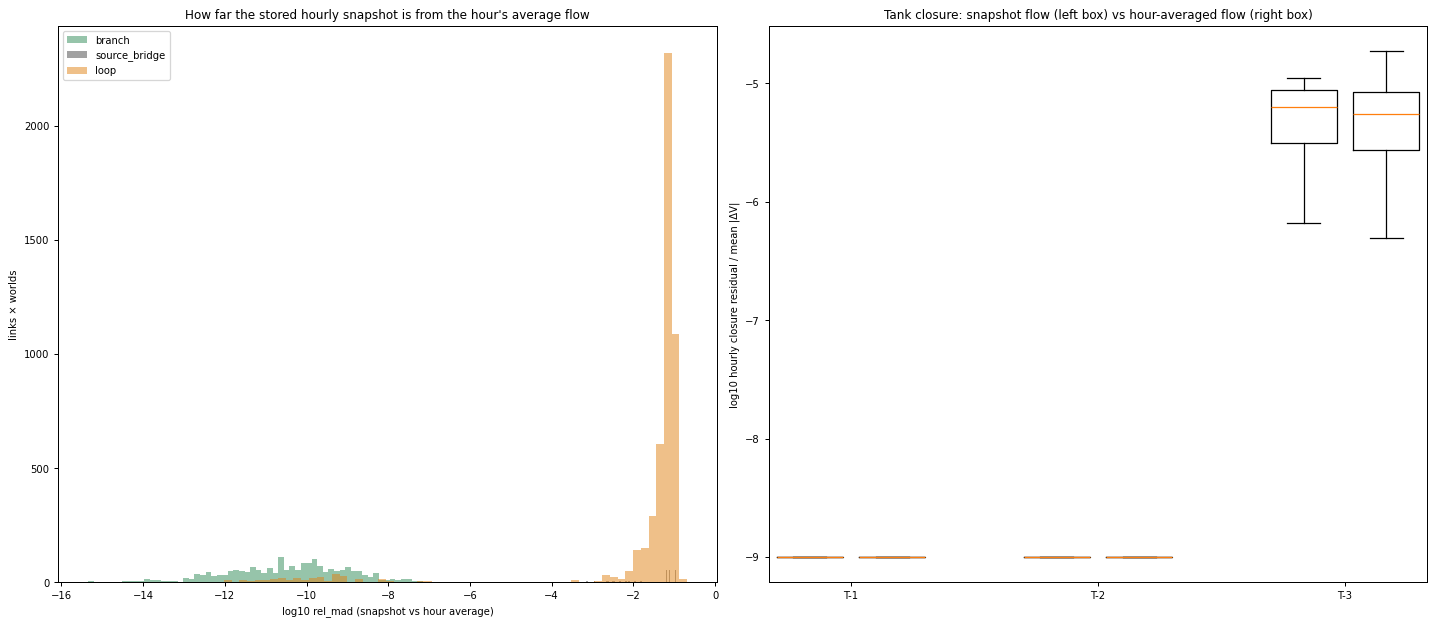

In [5]:
E0 = pd.DataFrame(E0_ROWS)
E0L = pd.concat(E0_LINK, ignore_index=True) if E0_LINK else pd.DataFrame()
E0T = pd.concat(E0_TANK, ignore_index=True) if E0_TANK else pd.DataFrame()
E0P = pd.DataFrame(E0_PUMP)
E0.to_parquet(OUT / "e0_world.parquet", index=False)
for name, df in (("e0_link", E0L), ("e0_tank_hourly", E0T), ("e0_pump", E0P)):
    if len(df):
        df.to_parquet(OUT / f"{name}.parquet", index=False)

G0 = [{"gate": "G-E0a re-run = stored flows", "value": f"{E0['E0a max rel |rerun - stored|'].max():.1e}",
       "passed": bool(E0["E0a max rel |rerun - stored|"].max() <= GATE_E0_REL)},
      {"gate": "G-E0a re-run = stored tank levels (m)", "value": f"{E0['E0a max |level diff| m'].max():.1e}",
       "passed": bool(E0["E0a max |level diff| m"].max() <= GATE_E0_LEVEL)},
      {"gate": "G-E0a pump states identical", "value": int(E0["E0a pump-hours mismatched"].sum()),
       "passed": bool(E0["E0a pump-hours mismatched"].sum() == 0)}]
if E0_TOOLKIT:
    G0 += [{"gate": "G-E0b toolkit loop = run_hydraulics", "value": f"{E0['E0b max rel |toolkit - rerun|'].max():.1e}",
            "passed": bool(E0["E0b max rel |toolkit - rerun|"].max() <= GATE_E0_REL)},
           {"gate": "G-E0c tank closure with hour averages", "value": f"{E0['E0c max tank closure (avg)'].max():.1e}",
            "passed": bool(E0["E0c max tank closure (avg)"].max() <= GATE_E0_CLOSURE)}]
if E0_TOOLKIT:
    G0.append(run_gate("E0"))
GT0 = pd.DataFrame(G0)
display(GT0)
display(Markdown("per world")); display(E0)
E0_OK = bool(GT0["passed"].all())
display(Markdown("**All E0 gates pass.**" if E0_OK else
                 "**An E0 gate failed — the re-simulation does not reproduce the stored worlds; E0c / E4 / E2 must not run.**"))

if E0_TOOLKIT and len(E0L):
    tp = TOPO.drop_duplicates("element").set_index("element")["topo"]
    E0L["topo"] = E0L["element"].map(tp).fillna("other")
    E0L["storage"] = [storage_of(m).get(e, np.nan) for m, e in zip(E0L["districting"], E0L["element"])]
    E0L["rel_mad"] = E0L["mad_snap_avg"] / E0L["mean_abs_flow"].where(E0L["mean_abs_flow"] > 0)
    E0L["rel_window_bias"] = (E0L["mean_snap"] - E0L["mean_avg"]).abs() / E0L["mean_abs_flow"].where(E0L["mean_abs_flow"] > 0)
    display(Markdown("**Snapshot vs hour-average, per link** (init window): mean $\\lvert q(t)-\\bar q_{[t,t+1h)}\\rvert$ / "
                     "mean $\\lvert q\\rvert$ (`rel_mad`) and the window-mean bias $\\lvert\\overline{q}^{snap}-\\overline{q}^{avg}\\rvert$ / "
                     "mean $\\lvert q\\rvert$ (`rel_window_bias`) — quantiles over links and worlds"))
    display(E0L.groupby(["districting", "topo"])[["rel_mad", "rel_window_bias"]]
            .quantile([0.5, 0.9, 0.99]).unstack().round(4))
    display(Markdown("by storage class (loops and source bridges)"))
    display(E0L[E0L["topo"] != "branch"].groupby(["districting", "storage"])[["rel_mad", "rel_window_bias"]]
            .quantile([0.5, 0.9]).unstack().round(4))
    E0T["rel_snap"] = E0T["res_snap"].abs() / E0T.groupby(["world", "tank"])["dV"].transform(lambda x: x.abs().mean())
    E0T["rel_avg"] = E0T["res_avg"].abs() / E0T.groupby(["world", "tank"])["dV"].transform(lambda x: x.abs().mean())
    cum = E0T.groupby(["districting", "world", "tank"]).agg(
        sum_dV=("dV", "sum"), sum_res_snap=("res_snap", "sum"), sum_res_avg=("res_avg", "sum"),
        gross=("dV", lambda x: x.abs().sum()))
    cum["net_bias_snap / gross"] = cum["sum_res_snap"] / cum["gross"]
    cum["net_bias_avg / gross"] = cum["sum_res_avg"] / cum["gross"]
    display(Markdown("**Tank volume closure** — hourly $\\lvert\\Delta V-\\bar q\\,\\Delta t\\rvert$ / mean $\\lvert\\Delta V\\rvert$ "
                     "with the snapshot flow vs the hour-averaged flow (quantiles), and the cumulative bias over the window"))
    display(E0T.groupby(["districting", "tank"])[["rel_snap", "rel_avg"]].quantile([0.5, 0.9, 0.99]).unstack().round(4))
    display(cum.groupby(["districting", "tank"])[["net_bias_snap / gross", "net_bias_avg / gross"]].median().round(5))
    display(Markdown("**Pumps** — switches seen at the hourly snapshots vs switches over all solver steps"))
    display(E0P.groupby(["districting", "pump"])[["switches_snapshots", "switches_all_steps", "on_frac_snap", "on_frac_avg"]]
            .median().round(3))

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for tp_, cc in (("branch", "#2e8b57"), ("source_bridge", "#444444"), ("loop", "#e08214")):
        z_ = E0L[(E0L["topo"] == tp_) & (E0L["rel_mad"] > 0)]["rel_mad"]
        if len(z_):
            axes[0].hist(np.log10(z_), bins=60, alpha=0.5, color=cc, label=tp_)
    axes[0].set(xlabel="log10 rel_mad (snapshot vs hour average)", ylabel="links × worlds",
                title="How far the stored hourly snapshot is from the hour's average flow")
    axes[0].legend()
    tl = sorted(E0T["tank"].unique())
    axes[1].boxplot([np.log10(E0T[E0T["tank"] == t]["rel_snap"].clip(1e-9)) for t in tl],
                    positions=np.arange(len(tl)) * 3, widths=0.8, showfliers=False)
    axes[1].boxplot([np.log10(E0T[E0T["tank"] == t]["rel_avg"].clip(1e-9)) for t in tl],
                    positions=np.arange(len(tl)) * 3 + 1, widths=0.8, showfliers=False)
    axes[1].set_xticks(np.arange(len(tl)) * 3 + 0.5, tl)
    axes[1].set(ylabel="log10 hourly closure residual / mean |ΔV|",
                title="Tank closure: snapshot flow (left box) vs hour-averaged flow (right box)")
    fig.tight_layout(); plt.show()

## Partitions

One world per partition (its init demand; E0 shows whether the partition's worlds share it). Horizon
$H$ = `H_MONTHS` months from hour 0; dose from month `STEP_MONTH`; analysis window $W$ from `SETTLE_DAYS` after the
step to $H$. Dose: every junction of $k$ scaled by $(1+\delta)$ from the step on, so
$\Delta D_k(t)=\delta\,D_k(t)$ in $W$ and every other demand is unchanged.

In [6]:
def assert_e0():
    if not (RUN_E0 and E0_OK):
        raise RuntimeError("E0 did not run or a gate failed — re-simulation is not trusted")


assert_e0()
PART = {}
for m, g in WORLDS.groupby("districting"):
    r = g.sort_values("drift_district").iloc[0]
    w = ATLAS.world(r["sim_hash"])
    tm = w.params["time"]
    if int(tm.get("resolution_h", 1)) != 1:
        raise ValueError("this notebook assumes hourly steps")
    sd, sm = 24, 24 * int(tm["days_per_month"])
    H, T_STEP = H_MONTHS * sm, STEP_MONTH * sm
    Wn = (T_STEP + SETTLE_DAYS * sd, H)
    i1 = int(dwx.at[r["sim_hash"][:8], "i1"])
    if H > i1:
        raise ValueError(f"{m}: horizon {H} h exceeds the init window ({i1} h) — runs must stay pre-drift")
    wn = build_model(w)
    D0 = w.catalog.load("demand_series").iloc[:H].reset_index(drop=True)
    D0.columns = [c if c == "month" else str(c) for c in D0.columns]
    dy = w.catalog.load("districts")
    node2d = {str(n): d for d, ns in dy["districts"].items() for n in ns}
    names = sorted(dy["districts"])
    kcols = {k: [c for c in D0.columns if node2d.get(c) == k] for k in names}
    LT = link_table(wn)
    DOWN = branch_downstream(wn, LT)
    PART[m] = {"world": w, "hash": r["sim_hash"][:8], "wn": wn, "D0": D0, "sd": sd, "H": H, "T_STEP": T_STEP,
               "W": Wn, "names": names, "kcols": kcols, "LT": LT, "DOWN": DOWN, "home": home_of(m),
               "storage": storage_of(m)}
    print(f"{m}: world {r['sim_hash'][:8]}, horizon {H} h, step at {T_STEP} h, window {Wn}, "
          f"districts {names}, branch links {len(DOWN)}")


def dosed(Pm, k, delta):
    # k's junction demand scaled by (1 + delta) from the step on; everything else identical
    D1 = Pm["D0"].copy()
    D1.loc[Pm["T_STEP"]:, Pm["kcols"][k]] *= (1.0 + delta)
    dD = (D1[Pm["kcols"][k]].sum(axis=1) - Pm["D0"][Pm["kcols"][k]].sum(axis=1)).to_numpy(float)
    return D1, dD


RUNS = {}                                                          # (m, k, delta, step) -> simulate() output

configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
fast_greedy: world 0b4750d3, horizon 1512 h, step at 504 h, window (672, 1512), districts ['District_A', 'District_B', 'District_C', 'District_D'], branch links 165
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
girvan_newman: world 35d8d9bc, horizon 1512 h, step at 504 h, window (672, 1512), districts ['District_A', 'District_B', 'District_C', 'District_D'], branch links 165
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
spectral: world 27ccb25e, horizon 1512 h, step at 504 h, window (672, 1512), districts ['District_A', 'District_B', 'District_C', 'District_D'], branch links 165


## E0c · Does the 1 h hydraulic step matter?

The pipeline solves with a 1 h hydraulic step; EPANET already shortens a step when a control fires or a tank hits a
limit, but tank levels are advanced with the flow at the start of each step. Same baseline at 3600, 900 and 300 s:
per link $\overline{\lvert q_{s}-q_{ref}\rvert}/\overline{\lvert q\rvert}$ over $W$ for 900 vs 3600, 300 vs 3600 and 300 vs 900 — convergence shows as 300 vs 900 being much smaller than 900 vs 3600 (snapshots, hour averages, window means), tank head
differences, pump switches. Then, at dose `E0C_DOSE` for every district, $g_w$ at 3600 s vs `FINE_STEPS[0]`:
if the gains do not move, a finer step would not change the labels.

In [7]:
assert_e0()
E0C_LINK, E0C_TANK, E0C_PUMP, E0C_GAIN = [], [], [], []
STEPS = [3600] + (FINE_STEPS if RUN_E0C else [])
PAIRS = [(3600, s) for s in FINE_STEPS] + ([(FINE_STEPS[0], FINE_STEPS[1])] if len(FINE_STEPS) > 1 else [])
for m, Pm in PART.items():
    H, (lo, hi), sd = Pm["H"], Pm["W"], Pm["sd"]
    for s in STEPS:
        RUNS[(m, None, 0.0, s)] = log_run(simulate(Pm["wn"], Pm["D0"], H, hyd_step=s),
                                          section="E0c", districting=m, step=s, k=None, delta=0.0)
    r0 = RUNS[(m, None, 0.0, 3600)]
    if not RUN_E0C:
        continue
    links = r0["links"]
    mq = np.abs(r0["avg"][lo:hi]).mean(axis=0)
    for ref, s in PAIRS:                      # each finer step against 3600 s, and the two finer steps directly
        ra, rf = RUNS[(m, None, 0.0, ref)], RUNS[(m, None, 0.0, s)]
        E0C_LINK.append(pd.DataFrame({
            "element": links, "mean_abs_flow": mq, "ref": ref, "step": s,
            "rel_snap": np.abs(rf["snap"] - ra["snap"])[lo:hi].mean(axis=0) / np.where(mq > 0, mq, np.nan),
            "rel_avg": np.abs(rf["avg"] - ra["avg"])[lo:hi].mean(axis=0) / np.where(mq > 0, mq, np.nan),
            "rel_window_mean": np.abs(rf["avg"][lo:hi].mean(axis=0) - ra["avg"][lo:hi].mean(axis=0))
            / np.where(mq > 0, mq, np.nan)}).assign(districting=m))
        for k, t in enumerate(r0["tanks"]):
            E0C_TANK.append({"districting": m, "ref": ref, "step": s, "tank": t,
                             "max_abs_head_diff_m": float(np.abs(rf["tank_head"][:, k] - ra["tank_head"][:, k]).max()),
                             "mean_abs_head_diff_m": float(np.abs(rf["tank_head"][:, k] - ra["tank_head"][:, k]).mean())})
        for k, p in enumerate(r0["pumps"]):
            E0C_PUMP.append({"districting": m, "ref": ref, "step": s, "pump": p,
                             "switches_ref": int(ra["switches"][k]), "switches_step": int(rf["switches"][k]),
                             "on_frac_ref": float(ra["on_frac"][lo:hi, k].mean()),
                             "on_frac_step": float(rf["on_frac"][lo:hi, k].mean())})
    # do the labels move? gains at E0C_DOSE for every district, 3600 s vs FINE_STEPS[0]
    sf = FINE_STEPS[0]
    rf0 = RUNS[(m, None, 0.0, sf)]
    for k in Pm["names"]:
        D1, dD = dosed(Pm, k, E0C_DOSE)
        if (m, k, E0C_DOSE, 3600) not in RUNS:
            RUNS[(m, k, E0C_DOSE, 3600)] = log_run(simulate(Pm["wn"], D1, H), section="E0c", districting=m,
                                                   step=3600, k=k, delta=E0C_DOSE)
        r1 = RUNS[(m, k, E0C_DOSE, 3600)]
        r1f = log_run(simulate(Pm["wn"], D1, H, hyd_step=sf), section="E0c", districting=m, step=sf, k=k,
                      delta=E0C_DOSE)
        for kind in ("snap", "avg"):
            gc = gains_of((r1[kind] - r0[kind])[lo:hi], dD[lo:hi], sd, lo)
            gf = gains_of((r1f[kind] - rf0[kind])[lo:hi], dD[lo:hi], sd, lo)
            E0C_GAIN.append(pd.DataFrame({"element": links, "k": k, "output": kind, "g_w_3600": gc[1],
                                          "g_w_fine": gf[1], "g_h_3600": gc[0], "g_h_fine": gf[0]})
                            .assign(districting=m, step=sf))
        del r1f
    for s in FINE_STEPS:
        RUNS.pop((m, None, 0.0, s), None)
    print(f"  E0c {m} done")

display(pd.DataFrame([run_gate("E0c")]))
if RUN_E0C:
    E0CL, E0CT = pd.concat(E0C_LINK, ignore_index=True), pd.DataFrame(E0C_TANK)
    E0CP, E0CG = pd.DataFrame(E0C_PUMP), pd.concat(E0C_GAIN, ignore_index=True)
    tp = TOPO.drop_duplicates("element").set_index("element")["topo"]
    for df in (E0CL, E0CG):
        df["topo"] = df["element"].map(tp).fillna("other")
    E0CG["own"] = [PART[m]["home"].get(e) == k for m, e, k in zip(E0CG["districting"], E0CG["element"], E0CG["k"])]
    E0CG["abs_dg"] = (E0CG["g_w_fine"] - E0CG["g_w_3600"]).abs()
    E0CG["rel_dg"] = E0CG["abs_dg"] / E0CG["g_w_3600"].abs().where(E0CG["g_w_3600"].abs() >= 1e-2)
    for name, df in (("e0c_link", E0CL), ("e0c_tank", E0CT), ("e0c_pump", E0CP), ("e0c_gain", E0CG)):
        df.to_parquet(OUT / f"{name}.parquet", index=False)
    display(Markdown("**Does a finer hydraulic step change the solution?** Per link, mean $\\lvert q_{step}-q_{ref}\\rvert$ / "
                     "mean $\\lvert q\\rvert$ over the analysis window (quantiles over links). If the solution has converged, "
                     f"{FINE_STEPS[-1]} vs {FINE_STEPS[0]} is much smaller than {FINE_STEPS[0]} vs 3600."))
    display(E0CL.groupby(["districting", "ref", "step", "topo"])[["rel_snap", "rel_avg", "rel_window_mean"]]
            .quantile([0.5, 0.9]).unstack().round(4))
    display(E0CT.pivot_table(index=["districting", "tank"], columns=["ref", "step"],
                             values=["max_abs_head_diff_m", "mean_abs_head_diff_m"]).round(3))
    display(E0CP[E0CP["switches_ref"] > 0])
    display(Markdown(f"**Do the gains move?** $\\lvert g_w^{{{FINE_STEPS[0]}}}-g_w^{{3600}}\\rvert$ at dose {E0C_DOSE:+.0%} "
                     "(absolute; relative where $\\lvert g_w^{3600}\\rvert\\geq 0.01$)"))
    display(E0CG.groupby(["districting", "output", "topo", "own"])[["abs_dg", "rel_dg"]]
            .quantile([0.5, 0.9, 0.99]).unstack().round(4))
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    for ax, kind in zip(axes, ("snap", "avg")):
        z_ = E0CG[E0CG["output"] == kind]
        for tp_, cc in (("branch", "#2e8b57"), ("source_bridge", "#444444"), ("loop", "#e08214")):
            q_ = z_[z_["topo"] == tp_]
            ax.scatter(q_["g_w_3600"], q_["g_w_fine"], s=5, alpha=0.4, color=cc, label=tp_)
        lim = np.nanpercentile(np.abs(z_[["g_w_3600", "g_w_fine"]].to_numpy(float)), 99.5)
        ax.plot([-lim, lim], [-lim, lim], color="0.5", lw=0.8)
        ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel="g_w, hydraulic step 3600 s",
               ylabel=f"g_w, hydraulic step {FINE_STEPS[0]} s", title=f"gains from {kind} flows")
    axes[0].legend(markerscale=3)
    fig.tight_layout(); plt.show()

,gate,value,passed
0,"G-run E0c: completed, converged",0 / 3 runs failing,True


## E4 · Dose–response

Per partition, district $k$ and dose $\delta$, with $\Delta Q_s=Q^{\delta}_s-Q^{0}_s$ on $W$ (snapshots and hour averages):

| quantity | definition | reading |
|---|---|---|
| $g_h$ | $\langle\Delta Q_s,\Delta D_k\rangle/\lVert\Delta D_k\rVert^2$ (hourly) | exact gain, L/s of link per L/s of $k$ |
| $g_w$ | same on weekly profiles $P(\cdot)$ — the study's gain with the paired difference | comparable with `sensor_evidence.g_tot` |
| $r^2_t$ | $1-\lVert\Delta Q_s-g_h\Delta D_k\rVert^2/\lVert\Delta Q_s\rVert^2$ | how much of the response is proportional to $\Delta D_k$ hour by hour |
| orientation | sign of the link's baseline mean flow on $W$ | as the study |
| linearity | $\lvert g(-20\%)/g(+20\%)-1\rvert$ (direction), $\lvert g(+5\%)/g(+20\%)-1\rvert$ (size), sign kept across doses; links with $\lvert g(+20\%)\rvert\ge0.01$, valid doses only | is the gain a property of the link? (U6) |
| drive $\gamma_{p,k}$ | $g_w$ of pump $p$'s on-state change $u_p\in\{0,1\}$ (at the snapshots, as the switch fit), and of its open fraction | U3: known hub drives |

| gate | rule |
|---|---|
| G-E4a | the baseline run twice is identical |
| G-E4b | branch links: $\lvert g_h-g^{ex}\rvert\le10^{-3}$, $g^{ex}$ from $\Delta Q_s=\sigma_s\sum_{n\in\text{down}(s)\cap k}\Delta d_n$ |
| G-run | every run completed and converged |

Validity: demand-driven hydraulics solve through negative pressure; each dose reports its minimum pressure over junctions
that carry demand, flagged (`pressure_ok = False`) when it goes below zero; pumps' open fraction and tanks' time at a level limit.

In [8]:
assert_e0()
E4_GAIN, E4_DRIVE, E4_RUN, E4_TANK, E4_BRANCH, E4_DET = [], [], [], [], [], []
TRAJ = {}                                                          # (m, k, delta) -> full run kept for E2
if RUN_E4:
    for m, Pm in PART.items():
        H, (lo, hi), sd, wn = Pm["H"], Pm["W"], Pm["sd"], Pm["wn"]
        r0 = RUNS.get((m, None, 0.0, 3600)) or log_run(simulate(wn, Pm["D0"], H), section="E4", districting=m,
                                                         k=None, delta=0.0)
        RUNS[(m, None, 0.0, 3600)] = r0
        r0b = log_run(simulate(wn, Pm["D0"], H), section="E4", districting=m, k=None, delta=0.0)   # determinism
        E4_DET.append({"districting": m, "max |rerun - run| L/s": float(np.abs(r0b["snap"] - r0["snap"]).max())})
        del r0b
        links, pumps = r0["links"], r0["pumps"]
        lix = {l: j for j, l in enumerate(links)}
        orient0 = orient_of(r0["snap"][lo:hi])
        mq0 = np.abs(r0["snap"][lo:hi]).mean(axis=0)
        U0 = {p: pump_on(r0["snap"][:, lix[p]]).astype(float) for p in pumps}
        TRAJ[(m, None, 0.0)] = r0
        tank_lim = {t: (Pm["wn"].get_node(t).elevation + Pm["wn"].get_node(t).min_level,
                        Pm["wn"].get_node(t).elevation + Pm["wn"].get_node(t).max_level) for t in r0["tanks"]}
        br = [l for l in links if l in Pm["DOWN"]]
        sig = np.array([1.0 if Pm["LT"].at[l, "end"] in Pm["DOWN"][l] else -1.0 for l in br])
        for k in Pm["names"]:
            kc = Pm["kcols"][k]
            Bk = np.array([[1.0 if c in Pm["DOWN"][l] else 0.0 for c in kc] for l in br]) if br else np.zeros((0, len(kc)))
            for delta in DOSES:
                D1, dD = dosed(Pm, k, delta)
                r1 = RUNS.pop((m, k, delta, 3600), None) or log_run(simulate(wn, D1, H), section="E4",
                                                                     districting=m, k=k, delta=delta)
                for kind in ("snap", "avg"):
                    g_h, g_w, r2t = gains_of((r1[kind] - r0[kind])[lo:hi], dD[lo:hi], sd, lo)
                    E4_GAIN.append(pd.DataFrame({
                        "element": links, "output": kind, "g_h_raw": g_h, "g_w_raw": g_w,
                        "g_h": g_h * orient0, "g_w": g_w * orient0, "r2_t": r2t, "orient": orient0,
                        "mean_abs_flow": mq0}).assign(districting=m, k=k, delta=delta))
                # drives: each pump's on-state change, projected on k's demand change
                for j, p in enumerate(pumps):
                    U1 = pump_on(r1["snap"][:, lix[p]]).astype(float)
                    _, gu, _ = gains_of((U1 - U0[p])[lo:hi, None], dD[lo:hi], sd, lo)
                    _, ga, _ = gains_of((r1["on_frac"][:, j] - r0["on_frac"][:, j])[lo:hi, None], dD[lo:hi], sd, lo)
                    E4_DRIVE.append({"districting": m, "k": k, "delta": delta, "pump": p,
                                     "gamma_snap": float(gu[0]), "gamma_avg": float(ga[0]),
                                     "on_frac_0": float(r0["on_frac"][lo:hi, j].mean()),
                                     "on_frac_1": float(r1["on_frac"][lo:hi, j].mean()),
                                     "switches_0": int(r0["switches"][j]), "switches_1": int(r1["switches"][j])})
                for j, t in enumerate(r1["tanks"]):
                    hmin, hmax = tank_lim[t]
                    E4_TANK.append({"districting": m, "k": k, "delta": delta, "tank": t,
                                    "head_mean_0": float(r0["tank_head"][lo:hi, j].mean()),
                                    "head_mean_1": float(r1["tank_head"][lo:hi, j].mean()),
                                    "frac_at_max_1": float((r1["tank_head"][lo:hi, j] >= hmax - 1e-3).mean()),
                                    "frac_at_min_1": float((r1["tank_head"][lo:hi, j] <= hmin + 1e-3).mean())})
                E4_RUN.append({"districting": m, "k": k, "delta": delta, "seconds": round(r1["seconds"], 1),
                               "steps per hour": r1["n_steps"] / H, "pmin_window": float(r1["pmin"][lo:hi].min()),
                               "pmin_window_0": float(r0["pmin"][lo:hi].min()),
                               "pressure_ok": bool(r1["pmin"][lo:hi].min() >= min(0.0, r0["pmin"][lo:hi].min() - PMIN_DROP)),
                               "pump_setting_varies": bool(np.nanstd(r1["med_setting"][:, [r1["meds"].index(p)
                                                                       for p in pumps if p in r1["meds"]]], axis=0).max() > 1e-9)
                               if pumps else False})
                # branch truth: dq_s(t) = sigma_s * sum of k's downstream demand changes
                if br:
                    dK = (D1[kc].to_numpy(float) - Pm["D0"][kc].to_numpy(float))[lo:hi]
                    exp_ = (dK @ Bk.T) * sig                                  # (T, n_branch)
                    got = (r1["snap"] - r0["snap"])[lo:hi][:, [lix[l] for l in br]]
                    g_ex = exp_.T @ dD[lo:hi] / float(dD[lo:hi] @ dD[lo:hi])
                    g_got = got.T @ dD[lo:hi] / float(dD[lo:hi] @ dD[lo:hi])
                    E4_BRANCH.append(pd.DataFrame({"element": br, "g_exact_raw": g_ex, "g_h_raw": g_got,
                                                   "abs_err_g": np.abs(g_got - g_ex),
                                                   "max_abs_err_Ls": np.abs(got - exp_).max(axis=0)})
                                     .assign(districting=m, k=k, delta=delta))
                if delta in E2_DOSES:
                    TRAJ[(m, k, delta)] = r1
                else:
                    del r1
                print(f"\r  E4 {m} {k} {delta:+.2f}            ", end="", flush=True)
    print()

  E4 spectral District_D +0.20                 


,gate,value,passed
0,G-E4a determinism (baseline run twice),0.0e+00,True
1,G-E4b branches = exact (gain),3.1e-07,True
2,"G-run E4: completed, converged",0 / 51 runs failing,True


**All E4 gates pass.**

**Physical validity of each dose** — minimum pressure over junctions that carry demand, in the analysis window (baseline in the first column). A dose whose minimum goes below zero is flagged `pressure_ok = False`: demand-driven hydraulics solve through negative pressure.

delta                      baseline   -0.2  -0.05   0.05    0.2
districting   k                                                
fast_greedy   District_A      31.22  31.40  31.26  31.18  32.10
              District_B      31.22  31.41  31.27  31.18  32.09
              District_C      31.22  33.22  31.83  30.59  29.80
              District_D      31.22  31.46  31.27  31.17  31.41
girvan_newman District_A      33.52  33.52  33.53  33.55  33.55
              District_B      33.52  33.58  33.52  33.55  33.52
              District_C      33.52  33.55  33.53  33.52  33.62
              District_D      33.52  33.57  33.52  33.56  33.50
spectral      District_A      33.64  33.53  33.72  33.56  33.44
              District_B      33.64  33.52  33.71  33.58  33.38
              District_C      33.64  33.69  33.67  33.60  33.57
              District_D      33.64  33.50  33.70  33.59  33.50

,districting,k,delta,pmin_window,pmin_window_0


...

frac_at_max_1                   frac_at_min_1                  
delta                      -0.20 -0.05  0.05  0.20         -0.20 -0.05  0.05  0.20
districting   tank                                                                
fast_greedy   T-1            1.0   1.0   1.0   1.0           0.0   0.0   0.0   0.0
              T-2            1.0   1.0   1.0   1.0           0.0   0.0   0.0   0.0
              T-3            0.0   0.0   0.0   0.0           0.0   0.0   0.0   0.0
girvan_newman T-1            1.0   1.0   1.0   1.0           0.0   0.0   0.0   0.0
              T-2            1.0   1.0   1.0   1.0           0.0   0.0   0.0   0.0
              T-3            0.0   0.0   0.0   0.0           0.0   0.0   0.0   0.0
spectral      T-1            1.0   1.0   1.0   1.0           0.0   0.0   0.0   0.0
              T-2            1.0   1.0   1.0   1.0           0.0   0.0   0.0   0.0
              T-3            0.0   0.0   0.0   0.0           0.0   0.0   0.0   0.0

**Linearity** — links with $\lvert g_w(+20\%)\rvert\geq0.01$, valid doses only: $\lvert g(-20\%)/g(+20\%)-1\rvert$ (direction), $\lvert g(+5\%)/g(+20\%)-1\rvert$ (size), share within 0.2, and the share whose gain keeps one sign across all doses

n  dev_sign_med  dev_size_med  within_02  sign_consistent
districting   topo          own   storage                                                             
fast_greedy   branch        True  False     66         0.000         0.000      1.000            1.000
              loop          False False     51         0.973         0.533      0.216            0.569
                                  True     741         0.980         0.457      0.013            0.525
                            True  False     82         0.028         0.010      0.951            0.976
                                  True     271         0.867         0.078      0.188            0.513
              source_bridge False True      36         0.960         0.241      0.000            0.667
                                  NaN        3         0.752         0.241      0.000            1.000
                            True  False      3         0.000         0.000      1.000            1.000
                                  True      12         0.907         0.063      0.000            0.167
                                  NaN        1         0.752         0.052      0.000            1.000
girvan_newman branch        True  False     79         0.000         0.000      1.000            1.000
              loop          False False     72         0.458         0.462      0.208            0.931
                                  True     577         0.417         0.658      0.184            0.893
                            True  False     96         0.018         0.013      0.958            1.000
                                  True     197         0.159         0.372      0.604            0.883
              source_bridge False True      36         0.285         0.742      0.222            0.778
                                  NaN        3         0.285         0.659      0.333            1.000
                            True  False      3         0.000         0.000      1.000            1.000
                                  True      12         0.304         1.209      0.167            1.000
                                  NaN        1         0.192         1.116      1.000            1.000
spectral      branch        False False      1         0.000         0.000      1.000            1.000
                            True  False     64         0.000         0.000      1.000            1.000
              loop          False False     50         0.666         0.996      0.100            0.940
                                  True     644         0.613         0.996      0.061            0.907
                            True  False     82         0.018         0.064      0.988            1.000
                                  True     207         0.095         0.638      0.671            0.821
              source_bridge False True      36         0.532         0.970      0.194            0.889
                                  NaN        3         0.291         0.970      0.333            1.000
                            True  False      3         0.000         0.000      1.000            1.000
                                  True      11         0.532         0.970      0.455            1.000
                                  NaN        1         0.906         0.902      0.000            1.000

**Snapshot vs hour-average gains** — $\lvert g_w^{avg}-g_w^{snap}\rvert$ (quantiles)

output                              abs_d                   rel_d                  
                                     0.50    0.90    0.99    0.50     0.90     0.99
districting   topo          own                                                    
fast_greedy   branch        False  0.0000  0.0000  0.0000     NaN      NaN      NaN
                            True   0.0000  0.0000  0.0000  0.0000   0.0000   0.0000
              loop          False  0.0115  0.1088  0.6397  0.7777   1.9270   9.5380
                            True   0.0092  0.1051  0.5912  0.2457   1.5502   6.4301
              source_bridge False  0.4305  0.9054  1.7466  0.6648  11.3460  11.8738
                            True   0.5366  0.7740  1.7466  0.6106   4.4625  13.3278
girvan_newman branch        False  0.0000  0.0000  0.0000     NaN      NaN      NaN
                            True   0.0000  0.0000  0.0000  0.0000   0.0000   0.0000
              loop          False  0.0043  0.0847  0.6799  0.4175   1.2729   3.1711
                            True   0.0016  0.0295  0.3110  0.0525   0.6637   1.9414
              source_bridge False  0.0403  0.7258  1.7537  0.3406   1.1633  19.2262
                            True   0.0321  1.3522  1.3522  0.0804   0.7598   0.7936
spectral      branch        False  0.0000  0.0000  0.0000  0.0000   0.0000   0.0000
                            True   0.0000  0.0000  0.0000  0.0000   0.0000   0.0000
              loop          False  0.0116  0.1264  0.7180  0.9626   1.1566   4.2314
                            True   0.0048  0.0574  0.3751  0.1769   1.0213   4.8036
              source_bridge False  0.4027  1.0127  1.0904  1.0148  24.9398  26.8505
                            True   0.4499  1.0843  1.0904  1.0332  27.3290  31.3843

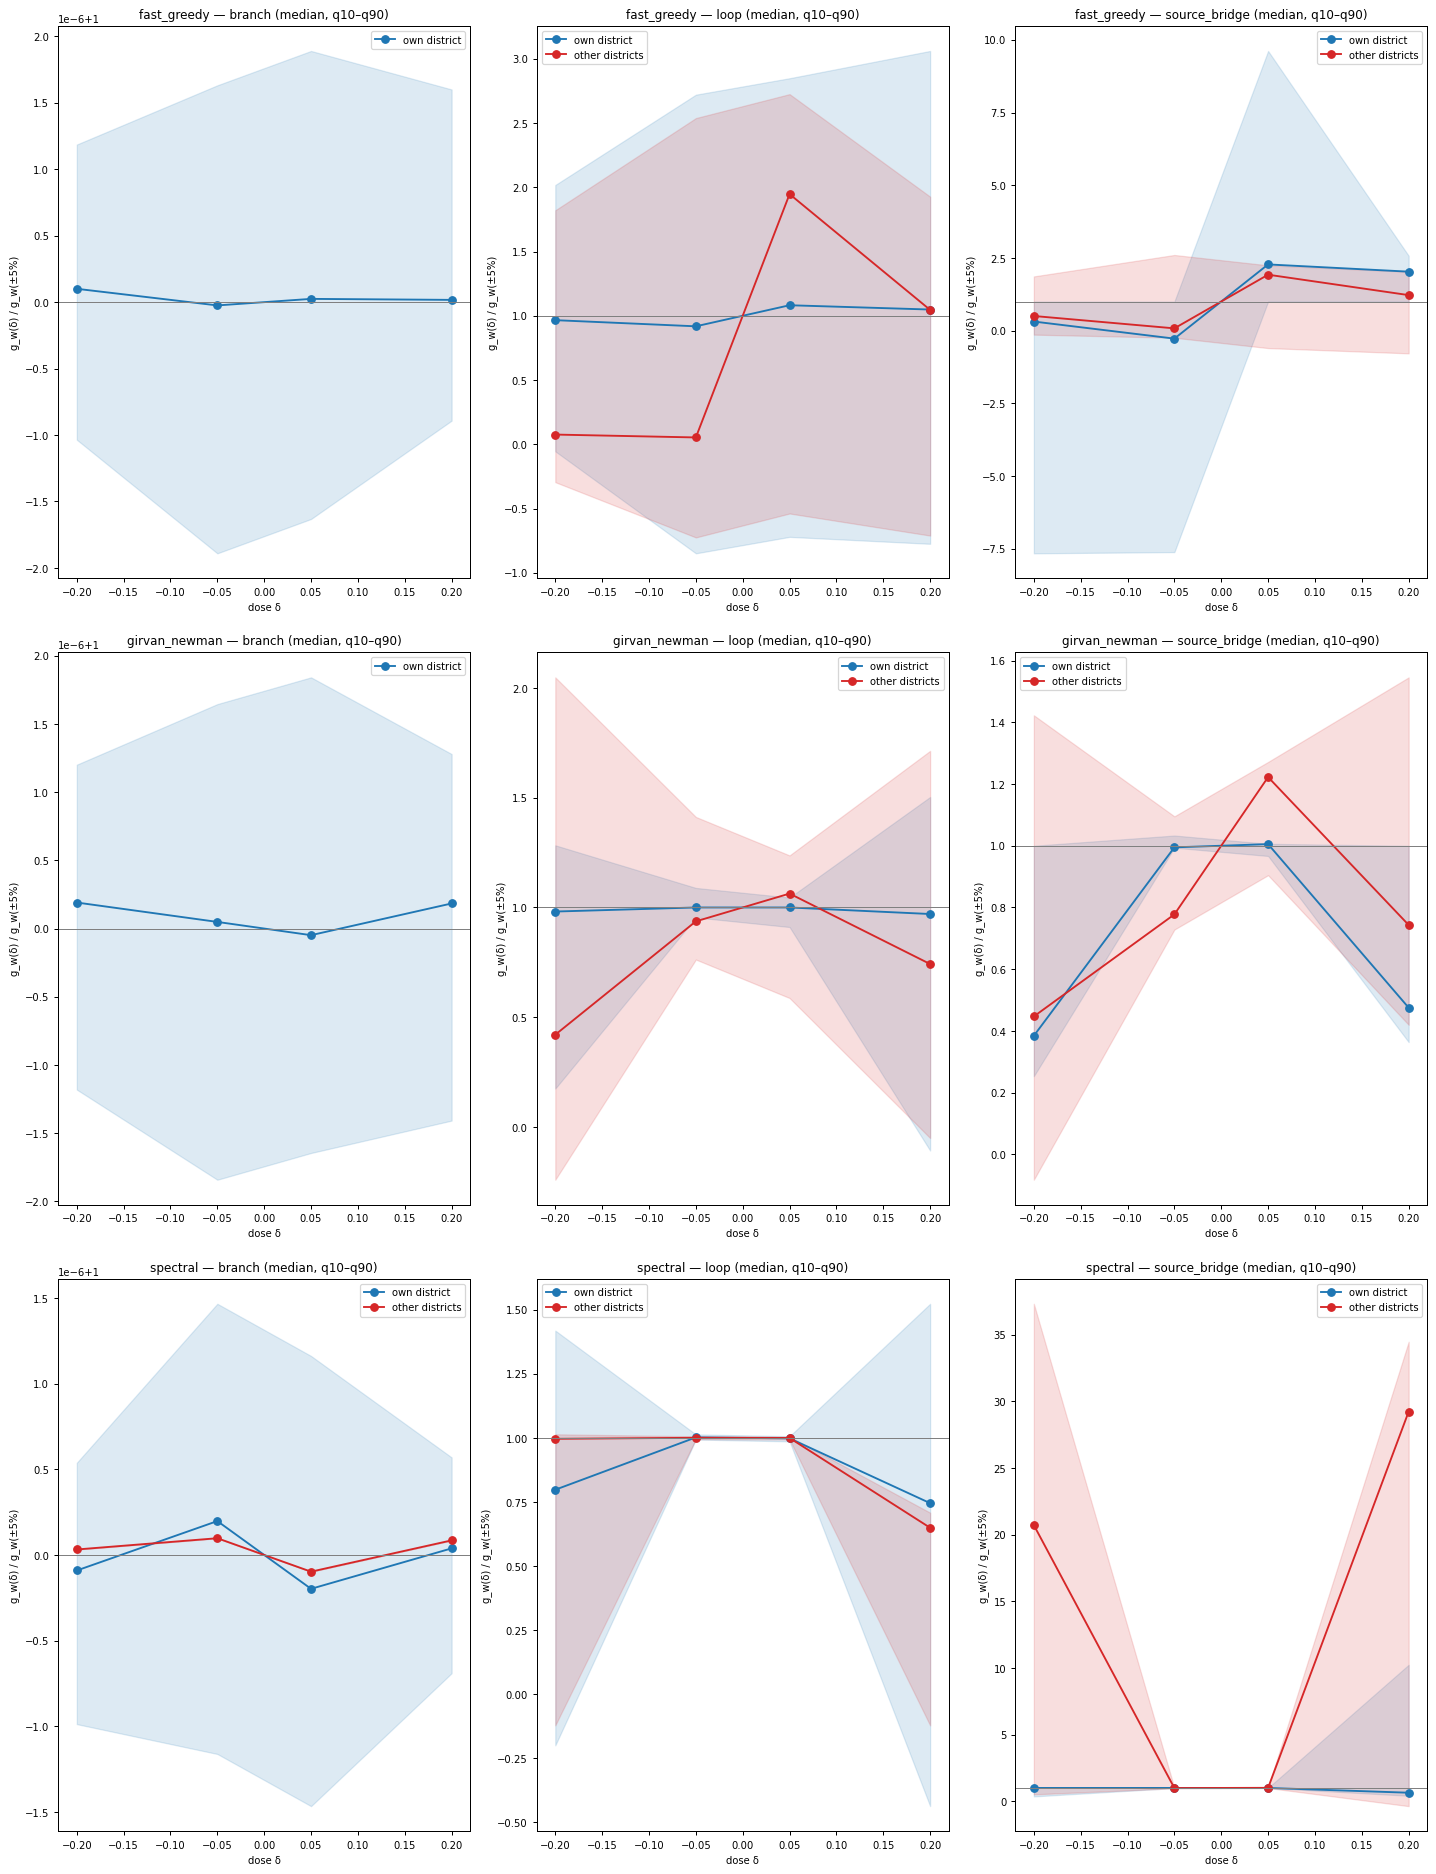

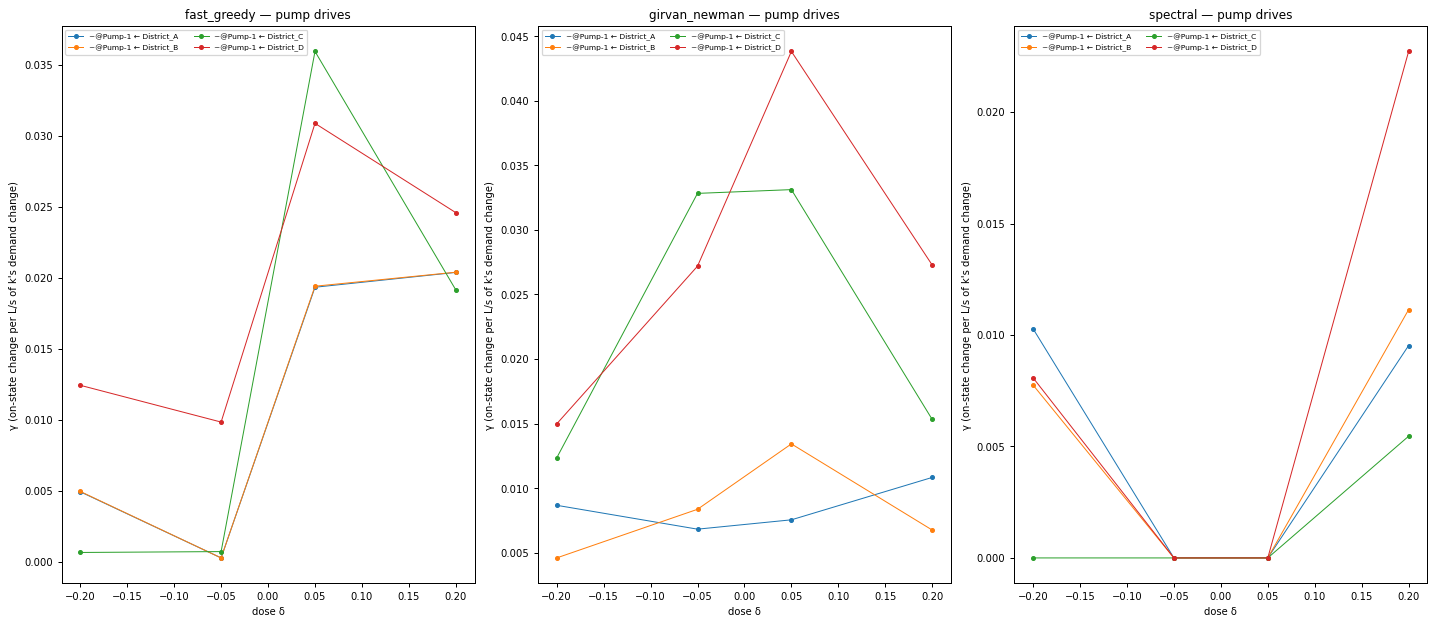

In [9]:
assert_e0()
E4G = pd.concat(E4_GAIN, ignore_index=True)
E4D, E4R, E4T = pd.DataFrame(E4_DRIVE), pd.DataFrame(E4_RUN), pd.DataFrame(E4_TANK)
E4B = pd.concat(E4_BRANCH, ignore_index=True) if E4_BRANCH else pd.DataFrame()
tp = TOPO.drop_duplicates("element").set_index("element")["topo"]
E4G["topo"] = E4G["element"].map(tp).fillna("other")
E4G["home"] = [PART[m]["home"].get(e) for m, e in zip(E4G["districting"], E4G["element"])]
E4G["own"] = E4G["home"] == E4G["k"]
E4G["storage"] = [PART[m]["storage"].get(e, np.nan) for m, e in zip(E4G["districting"], E4G["element"])]
E4G = E4G.merge(E4R[["districting", "k", "delta", "pressure_ok"]], on=["districting", "k", "delta"], how="left")
for name, df in (("e4_gain", E4G), ("e4_drive", E4D), ("e4_run", E4R), ("e4_tank", E4T), ("e4_branch", E4B)):
    if len(df):
        df.to_parquet(OUT / f"{name}.parquet", index=False)

G4 = [{"gate": "G-E4a determinism (baseline run twice)", "value": f"{pd.DataFrame(E4_DET)['max |rerun - run| L/s'].max():.1e}",
       "passed": bool(pd.DataFrame(E4_DET)["max |rerun - run| L/s"].max() == 0.0)},
      {"gate": "G-E4b branches = exact (gain)", "value": f"{E4B['abs_err_g'].max():.1e}" if len(E4B) else "n/a",
       "passed": bool(len(E4B) and E4B["abs_err_g"].max() <= GATE_E4_BRANCH)}]
G4.append(run_gate("E4"))
GT4 = pd.DataFrame(G4)
display(GT4)
E4_OK = bool(GT4["passed"].all())
display(Markdown("**All E4 gates pass.**" if E4_OK else "**An E4 gate failed — do not read E4 / E2 below.**"))
display(Markdown("**Physical validity of each dose** — minimum pressure over junctions that carry demand, in the analysis "
                 "window (baseline in the first column). A dose whose minimum goes below zero is flagged `pressure_ok = False`: "
                 "demand-driven hydraulics solve through negative pressure."))
pv = E4R.pivot_table(index=["districting", "k"], columns="delta", values="pmin_window").round(2)
pv.insert(0, "baseline", E4R.groupby(["districting", "k"])["pmin_window_0"].first().round(2))
display(pv)
display(E4R[~E4R["pressure_ok"]][["districting", "k", "delta", "pmin_window", "pmin_window_0"]])
display(Markdown("**Saturation** — pumps' open fraction in the window, baseline → dose (median over districts)"))
display(E4D.groupby(["districting", "pump", "delta"])[["on_frac_0", "on_frac_1"]].median().unstack("delta").round(3))
display(Markdown("tank time at a level limit in the dosed run"))
display(E4T.groupby(["districting", "tank", "delta"])[["frac_at_max_1", "frac_at_min_1"]].max().unstack("delta").round(3))

# dose-response: g(delta) / mean(g(+5%), g(-5%)) for links with a clear small-dose response (figure)
S_ = E4G[(E4G["output"] == "snap") & E4G["pressure_ok"]]
small = S_[S_["delta"].abs() == 0.05].groupby(["districting", "k", "element"])["g_w"].mean().rename("g_small")
S_ = S_.join(small, on=["districting", "k", "element"])
S_["ratio"] = S_["g_w"] / S_["g_small"].where(S_["g_small"].abs() >= 1e-2)
# linearity: is the gain a property of the link? compare -20 % with +20 % and +5 % with +20 % (valid doses only)
LP = S_.pivot_table(index=["districting", "k", "element", "topo", "own", "storage"], columns="delta",
                    values="g_w", dropna=False)
LP = LP.reindex(columns=DOSES).reset_index()
LP = LP[LP[0.2].abs() >= 1e-2]
LP["dev_sign"] = (LP[-0.2] / LP[0.2] - 1).abs()
LP["dev_size"] = (LP[0.05] / LP[0.2] - 1).abs()
LP["sign_consistent"] = np.sign(LP[[d for d in DOSES if d in LP]]).nunique(axis=1) == 1
LP.columns = [str(c) for c in LP.columns]
LP.to_parquet(OUT / "e4_linearity.parquet", index=False)
display(Markdown("**Linearity** — links with $\\lvert g_w(+20\\%)\\rvert\\geq0.01$, valid doses only: "
                 "$\\lvert g(-20\\%)/g(+20\\%)-1\\rvert$ (direction), $\\lvert g(+5\\%)/g(+20\\%)-1\\rvert$ (size), share within 0.2, "
                 "and the share whose gain keeps one sign across all doses"))
display(LP.groupby(["districting", "topo", "own", "storage"], dropna=False).agg(
    n=("element", "size"), dev_sign_med=("dev_sign", "median"), dev_size_med=("dev_size", "median"),
    within_02=("dev_sign", lambda x: (x < 0.2).mean()), sign_consistent=("sign_consistent", "mean")).round(3))
display(Markdown("**Snapshot vs hour-average gains** — $\\lvert g_w^{avg}-g_w^{snap}\\rvert$ (quantiles)"))
SA = E4G.pivot_table(index=["districting", "k", "delta", "element", "topo", "own"], columns="output", values="g_w").reset_index()
SA["abs_d"] = (SA["avg"] - SA["snap"]).abs()
SA["rel_d"] = SA["abs_d"] / SA["snap"].abs().where(SA["snap"].abs() >= 1e-2)
display(SA.groupby(["districting", "topo", "own"])[["abs_d", "rel_d"]].quantile([0.5, 0.9, 0.99]).unstack().round(4))

parts = list(PART)
fig, axes = plt.subplots(len(parts), 3, figsize=(16, 7 * len(parts)), squeeze=False)
for i, m in enumerate(parts):
    z_ = S_[(S_["districting"] == m) & S_["ratio"].notna()]
    for j, tp_ in enumerate(("branch", "loop", "source_bridge")):
        ax = axes[i, j]
        for own, cc in ((True, "#1f77b4"), (False, "#d62728")):
            q_ = z_[(z_["topo"] == tp_) & (z_["own"] == own)]
            if not len(q_):
                continue
            st = q_.groupby("delta")["ratio"].quantile([0.1, 0.5, 0.9]).unstack()
            ax.plot(st.index, st[0.5], marker="o", color=cc, label=("own district" if own else "other districts"))
            ax.fill_between(st.index, st[0.1], st[0.9], color=cc, alpha=0.15)
        ax.axhline(1, color="0.5", lw=0.8)
        ax.set(xlabel="dose δ", ylabel="g_w(δ) / g_w(±5%)", title=f"{m} — {tp_} (median, q10–q90)")
        ax.legend()
fig.tight_layout(); plt.show()

fig, axes = plt.subplots(1, len(parts), figsize=(16, 7), squeeze=False)
for i, m in enumerate(parts):
    ax = axes[0, i]
    z_ = E4D[E4D["districting"] == m]
    for (p, k), q_ in z_.groupby(["pump", "k"]):
        if q_["gamma_snap"].abs().max() > 0:
            ax.plot(q_["delta"], q_["gamma_snap"], marker=".", lw=0.8, label=f"{p} ← {k}")
    ax.set(xlabel="dose δ", ylabel="γ (on-state change per L/s of k's demand change)", title=f"{m} — pump drives")
    ax.legend(fontsize=6, ncol=2)
fig.tight_layout(); plt.show()

### E4 vs the study's evidence (U3)

Per partition × district × link: the study's oriented $g_{tot}$, $z_{tot}$ and significance (`sensor_evidence`, land-use
drift in the target worlds) against E4's exact $g_w$ at `E0C_DOSE`, in the study's orientation. Spearman of the gains;
AUC of $z_{tot}$ for an E4 response above $\varepsilon$; $P(\text{significant})$ where E4 has no response and where it has one.
**The excitations differ** (shape-changing conversion along a diffusion front vs uniform scaling of every junction of
$k$), so on loops a gain mismatch can be routing, not estimator error; on branches the two must agree in kind.

**Study evidence vs E4's exact response** (dose +20%, snapshot gains). The excitations differ: the study drifts by land-use conversion along a diffusion front, E4 scales every junction of $k$ uniformly — so a different gain is not by itself an error of the study's estimator.

,districting,topo,own,n,Spearman g_tot vs g_e4,AUC z_tot -> |g_e4|>0.001,P(sig | |g_e4|<=0.001),P(sig | |g_e4|>0.001),AUC z_tot -> |g_e4|>0.003,P(sig | |g_e4|<=0.003),P(sig | |g_e4|>0.003),AUC z_tot -> |g_e4|>0.01,P(sig | |g_e4|<=0.01),P(sig | |g_e4|>0.01),"sign agree (sig, |g_e4|>3e-3)"
0,fast_greedy,branch,False,495,0.028,NaN,0.051,NaN,NaN,0.051,NaN,NaN,0.051,NaN,NaN
1,fast_greedy,branch,True,165,1.000,0.739,1.000,1.000,0.507,1.000,1.000,0.493,1.000,1.000,1.000
2,fast_greedy,loop,False,1263,0.436,0.770,0.255,0.735,0.726,0.358,0.746,0.688,0.452,0.787,0.711
3,fast_greedy,loop,True,421,0.805,0.836,0.400,0.885,0.772,0.562,0.891,0.612,0.691,0.915,0.942
4,fast_greedy,source_bridge,False,51,0.592,1.000,0.000,1.000,1.000,0.000,1.000,1.000,0.000,1.000,0.667
5,fast_greedy,source_bridge,True,17,0.775,0.875,0.000,0.750,0.875,0.000,0.750,0.967,0.000,0.800,0.667
6,girvan_newman,branch,False,495,0.066,NaN,0.051,NaN,NaN,0.051,NaN,NaN,0.051,NaN,NaN
7,girvan_newman,branch,True,165,1.000,0.723,1.000,1.000,0.730,1.000,1.000,0.715,1.000,1.000,1.000
8,girvan_newman,loop,False,1263,0.868,0.820,0.143,0.665,0.827,0.195,0.729,0.807,0.318,0.814,0.986
9,girvan_newman,loop,True,421,0.952,0.879,0.300,0.880,0.833,0.467,0.899,0.817,0.609,0.959,0.994


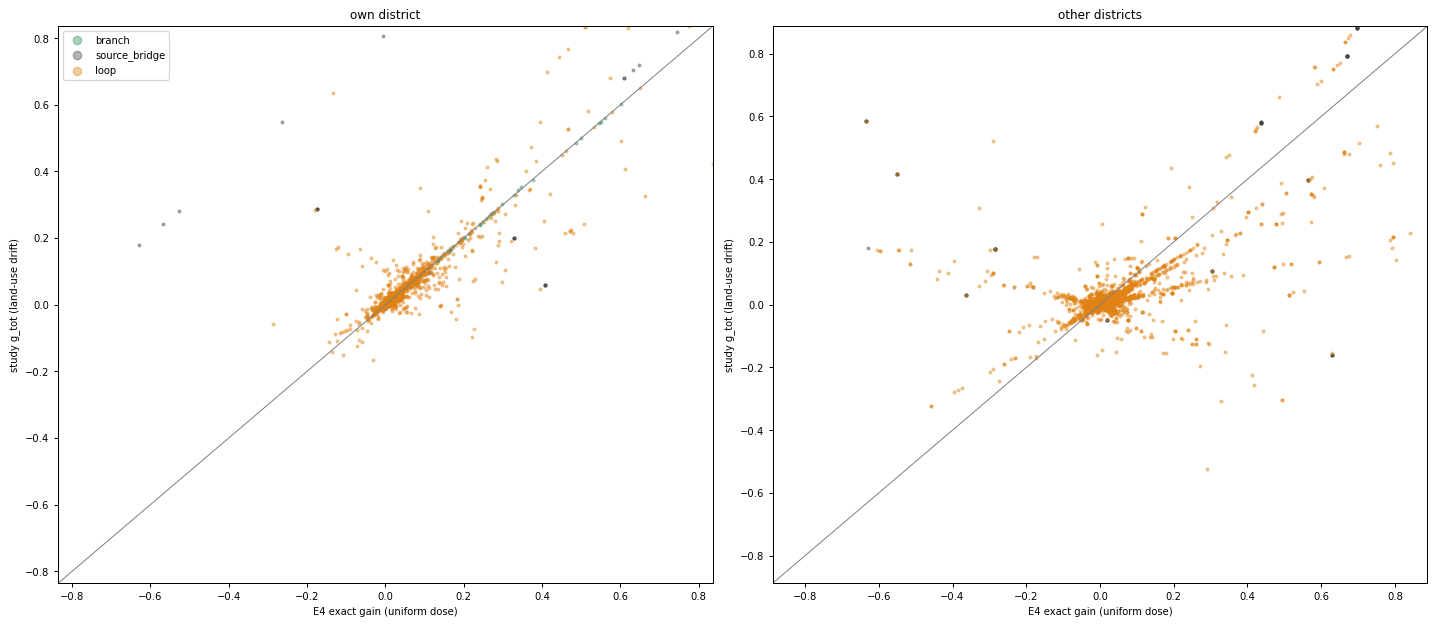

In [10]:
assert_e0()
# the study's interventional evidence (land-use drift, probe-free target worlds) next to E4's exact uniform-dose gain
ref = E4G[(E4G["output"] == "snap") & (E4G["delta"] == E0C_DOSE)][
    ["districting", "k", "element", "g_w_raw", "topo", "own", "storage"]]
se_ = SE.assign(element=SE["element"].astype(str))[["districting", "drift", "element", "g_tot", "orient", "z_tot",
                                                      "sig_tot", "c_nat"]].rename(columns={"drift": "k"})
CMP4 = ref.merge(se_, on=["districting", "k", "element"], how="inner")
CMP4["g_e4"] = CMP4["g_w_raw"] * CMP4["orient"]                  # E4 gain in the study's orientation
CMP4.to_parquet(OUT / "e4_vs_study.parquet", index=False)
rows = []
for (m, tp_, own), g in CMP4.groupby(["districting", "topo", "own"]):
    row = {"districting": m, "topo": tp_, "own": own, "n": len(g), "Spearman g_tot vs g_e4": spear(g["g_tot"], g["g_e4"])}
    for e in EPS_RESP:
        nz = g["g_e4"].abs() > e
        row[f"AUC z_tot -> |g_e4|>{e:g}"] = auc(g[nz]["z_tot"], g[~nz]["z_tot"])
        row[f"P(sig | |g_e4|<={e:g})"] = float(g[~nz]["sig_tot"].mean()) if (~nz).any() else np.nan
        row[f"P(sig | |g_e4|>{e:g})"] = float(g[nz]["sig_tot"].mean()) if nz.any() else np.nan
    sg = g[(g["g_e4"].abs() > EPS_RESP[1]) & g["sig_tot"]]
    row["sign agree (sig, |g_e4|>3e-3)"] = float((np.sign(sg["g_tot"]) == np.sign(sg["g_e4"])).mean()) if len(sg) else np.nan
    rows.append(row)
display(Markdown(f"**Study evidence vs E4's exact response** (dose {E0C_DOSE:+.0%}, snapshot gains). The excitations differ: "
                 "the study drifts by land-use conversion along a diffusion front, E4 scales every junction of $k$ "
                 "uniformly — so a different gain is not by itself an error of the study's estimator."))
display(pd.DataFrame(rows).round(3))
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, own in zip(axes, (True, False)):
    z_ = CMP4[CMP4["own"] == own]
    for tp_, cc in (("branch", "#2e8b57"), ("source_bridge", "#444444"), ("loop", "#e08214")):
        q_ = z_[z_["topo"] == tp_]
        ax.scatter(q_["g_e4"], q_["g_tot"], s=5, alpha=0.4, color=cc, label=tp_)
    lim = np.nanpercentile(np.abs(z_[["g_e4", "g_tot"]].to_numpy(float)), 99) if len(z_) else 1
    ax.plot([-lim, lim], [-lim, lim], color="0.5", lw=0.8)
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel="E4 exact gain (uniform dose)", ylabel="study g_tot (land-use drift)",
           title="own district" if own else "other districts")
axes[0].legend(markerscale=3)
fig.tight_layout(); plt.show()

## E2 · Mediator-blocked runs

For each partition, mode, district $k$ and $\delta\in$ `E2_DOSES`, with $F_0$ / $F_\delta$ the full baseline / dosed runs and
$B(\text{demand},\text{trajectory})$ the blocked twin:

| term | definition | meaning |
|---|---|---|
| total | $F_\delta-F_0$ | the response |
| direct, baseline mediators $DE_0$ | $B(\delta,F_0)-B(0,F_0)$ | demand channel with pumps, valves and tanks on their undosed course |
| direct, dosed mediators $DE_1$ | $B(\delta,F_\delta)-B(0,F_\delta)$ | the same, on the dosed course |
| storage $IE_0$, $IE_1$ | total − $DE_0$, total − $DE_1$ | the part that goes through the mediators |
| interaction | $\lvert DE_1-DE_0\rvert/(\lvert DE_0\rvert+\lvert IE_0\rvert)$ | if large, the split is not unique |
| switch-fit storage | $\sum_p b_{s,p}\gamma_{p,k}$: $b$ from `switch_b` (this partition's init window), $\gamma$ from E4's dosed run | the study's estimator, on the same excitation |

Each term is turned into a gain $g_w$ against $\Delta D_k$ on $W$ (snapshots, unoriented).

| gate | rule | why |
|---|---|---|
| G-E2run | every blocked run completed and converged | a silent halt reads as zeros (v1's likely failure) |
| G-E2h | every hour has an open path from each junction to a reservoir | M2 replaces tanks by fixed flows: with the source pumps closed the solve has no head reference |
| G-E2a | $B(0,F_0)$ reproduces $F_0$: max $\lvert\Delta q\rvert$ / mean $\lvert q\rvert\le$ 5e-4 (links above the flow floor) | the twin is faithful where nothing changes |
| G-E2b | $B(\delta,F_\delta)$ reproduces $F_\delta$, same bound | the twin is faithful on the dosed course |
| G-E2c | storage gain on branches $\le10^{-3}$ | branches carry no storage by physics |

Gates are per mode; a mode that fails is reported and left out. M1 and M2 disagree wherever a fixed head and a fixed
flow route $k$'s extra water differently — the comparison is part of the result.

Diagnostics: `e2_gate_hourly` (per run and hour, the largest relative departure and its link), `e2_mediators` (each held
link, its kind, status changes and settings), and the hours above the gate with the links that are worst there.

In [11]:
assert_e0()
if not E4_OK:
    raise RuntimeError("an E4 gate failed — E2 is built on E4's runs")
E2_LINK, E2_GATE, E2_HOURLY, E2_MED = [], [], [], []


def gate_rows(rb, r_ref, ixb, links, meta, gate):
    # run-level and hourly reproduction error of a blocked twin against the run it copies
    A, B = rb["snap"][:, ixb], r_ref["snap"]
    rd = rel_dev(A, B, FLOW_FLOOR)
    m_ = np.abs(B).mean(axis=0)
    keep = np.isfinite(rd)
    eh = (np.abs(A - B)[:, keep] / np.where(m_[keep] > 0, m_[keep], 1.0))
    E2_HOURLY.append(pd.DataFrame({"hour": np.arange(len(eh)), "max_rel": eh.max(axis=1),
                                   "worst": np.array(links)[keep][eh.argmax(axis=1)]}).assign(**meta, gate=gate))
    E2_GATE.append({**meta, "gate": gate, "max_rel": float(np.nanmax(rd)), "worst": links[int(np.nanargmax(rd))],
                    "hours_above_gate": int((eh.max(axis=1) > GATE_E2_REL).sum()),
                    "completed": bool(rb["completed"]), "unbalanced_steps": int(rb["warnings"].get(1, 0))})


if RUN_E2:
    for m, Pm in PART.items():
        H, (lo, hi), sd, wn = Pm["H"], Pm["W"], Pm["sd"], Pm["wn"]
        r0 = TRAJ[(m, None, 0.0)]
        links = r0["links"]
        lix = {l: j for j, l in enumerate(links)}
        pnodes = [c for c in Pm["D0"].columns if c != "month" and float(Pm["D0"][c].abs().max()) > 0]
        # mediators of this model and what the baseline does with them
        for j, md in enumerate(r0["meds"]):
            kind = "pump" if md in wn.pump_name_list else "valve" if md in wn.valve_name_list else "pipe"
            st, z = r0["med_status"][:, j], r0["med_setting"][:, j]
            E2_MED.append({"districting": m, "mediator": md, "kind": kind,
                           "type": getattr(wn.get_link(md), "valve_type", None) if kind == "valve" else None,
                           "status_changes": int((np.diff(st > 0.5)).sum()), "open_frac": float((st > 0.5).mean()),
                           "settings_when_open": ",".join(f"{v:g}" for v in np.unique(np.round(z[st > 0.5], 4))[:6])})
        # switch-fit storage prediction: b (study, init window of this partition) x gamma (E4's own run)
        idel = LBf[LBf["districting"] == m].drop_duplicates("id").set_index("id")["element"].astype(str)
        sb = SWB[(SWB["districting"] == m) & (SWB["world"] == Pm["hash"])].copy()
        if not len(sb):
            sb = SWB[SWB["districting"] == m].drop_duplicates(["id", "pump"]).copy()
        sb["element"] = sb["id"].map(idel)
        Bm = sb.pivot_table(index="element", columns="pump", values="b").reindex(links)
        for mode in MODES:
            wb, dem, info0 = blocked_model(wn, Pm["D0"], r0, mode, H)
            b00 = log_run(simulate(wb, dem, H, pmin_nodes=pnodes), section="E2", districting=m, mode=mode,
                          k=None, delta=0.0)
            ixb = [b00["links"].index(l) for l in links]
            meta0 = {"districting": m, "mode": mode, "k": None, "delta": 0.0,
                     "ill_posed_hours": info0["ill_posed_hours"], "controls": len(list(wb.controls()))}
            gate_rows(b00, r0, ixb, links, meta0, "a: blocked(0) = baseline")
            for k in Pm["names"]:
                for delta in E2_DOSES:
                    D1, dD = dosed(Pm, k, delta)
                    r1 = TRAJ[(m, k, delta)]
                    meta = {"districting": m, "mode": mode, "k": k, "delta": delta}
                    wb, dem1, _ = blocked_model(wn, D1, r0, mode, H)
                    b0d = log_run(simulate(wb, dem1, H, pmin_nodes=pnodes), section="E2", **meta, run="b0d")
                    wb, dem0, _ = blocked_model(wn, Pm["D0"], r1, mode, H)
                    b10 = log_run(simulate(wb, dem0, H, pmin_nodes=pnodes), section="E2", **meta, run="b10")
                    wb, dem1b, info1 = blocked_model(wn, D1, r1, mode, H)
                    b1d = log_run(simulate(wb, dem1b, H, pmin_nodes=pnodes), section="E2", **meta, run="b1d")
                    gate_rows(b1d, r1, ixb, links, {**meta, "ill_posed_hours": info1["ill_posed_hours"],
                                                    "controls": len(list(wb.controls()))},
                              "b: blocked(dose, dosed trajectory) = dosed run")
                    S0, S0d = b00["snap"][:, ixb], b0d["snap"][:, ixb]
                    S10, S1d = b10["snap"][:, ixb], b1d["snap"][:, ixb]
                    dDw = dD[lo:hi]
                    g = {}
                    for nm, X in (("tot", r1["snap"] - r0["snap"]), ("de0", S0d - S0), ("de1", S1d - S10)):
                        g[nm] = gains_of(X[lo:hi], dDw, sd, lo)[1]
                    gam = {}
                    for p in Bm.columns:
                        if p in lix:
                            U0 = pump_on(r0["snap"][:, lix[p]]).astype(float)
                            U1 = pump_on(r1["snap"][:, lix[p]]).astype(float)
                            gam[p] = float(gains_of((U1 - U0)[lo:hi, None], dDw, sd, lo)[1][0])
                    gv = np.array([gam.get(p, 0.0) for p in Bm.columns])
                    g_sto_pred = np.nan_to_num(Bm.to_numpy(float)) @ gv
                    g_sto_pred = np.where(Bm.notna().any(axis=1).to_numpy(), g_sto_pred, np.nan)
                    E2_LINK.append(pd.DataFrame({
                        "element": links, "g_tot": g["tot"], "g_de0": g["de0"], "g_de1": g["de1"],
                        "g_ie0": g["tot"] - g["de0"], "g_ie1": g["tot"] - g["de1"], "g_sto_pred": g_sto_pred,
                        "mean_abs_flow": np.abs(r0["snap"][lo:hi]).mean(axis=0)}).assign(**meta))
                    del b0d, b10, b1d
                    print(f"\r  E2 {m} {mode} {k} {delta:+.2f}            ", end="", flush=True)
            del b00
    print()
    pd.DataFrame(E2_MED).to_parquet(OUT / "e2_mediators.parquet", index=False)
    pd.concat(E2_HOURLY, ignore_index=True).to_parquet(OUT / "e2_gate_hourly.parquet", index=False)
    display(Markdown("**Mediators** (what the blocked twin holds fixed) and their baseline behaviour"))
    display(pd.DataFrame(E2_MED))

  E2 spectral M2 District_D +0.20                 


**Mediators** (what the blocked twin holds fixed) and their baseline behaviour

,districting,mediator,kind,type,status_changes,open_frac,settings_when_open
0,fast_greedy,~@Pump-1,pump,None,122,0.560847,1
1,girvan_newman,~@Pump-1,pump,None,122,0.556217,1
2,spectral,~@Pump-1,pump,None,122,0.561508,1


,mode,gate,value,passed
0,M1,G-E2run every blocked run completed and converged,0 failing,True
1,M1,G-E2h every hour has a head reference,0,True
2,M1,G-E2a blocked(0) reproduces the baseline,5.2e-03,False
3,M1,"G-E2b blocked(dose, dosed trajectory) reproduc...",8.1e-03,False
4,M1,G-E2c no storage channel on branches,1.3e-07,True
5,M2,G-E2run every blocked run completed and converged,48 failing,False
6,M2,G-E2h every hour has a head reference,702,False
7,M2,G-E2a blocked(0) reproduces the baseline,2.2e+02,False
8,M2,"G-E2b blocked(dose, dosed trajectory) reproduc...",2.2e+02,False
9,M2,G-E2c no storage channel on branches,8.6e+00,False


per run (worst link, hours above the gate)

,districting,mode,k,delta,ill_posed_hours,controls,gate,max_rel,worst,hours_above_gate,completed,unbalanced_steps
27,girvan_newman,M2,None,0.0,671,122,a: blocked(0) = baseline,216.210359,P-157,1489,True,0
28,girvan_newman,M2,District_A,-0.2,702,122,"b: blocked(dose, dosed trajectory) = dosed run",216.210359,P-157,1489,True,0
30,girvan_newman,M2,District_B,-0.2,684,122,"b: blocked(dose, dosed trajectory) = dosed run",216.210359,P-157,1489,True,0
31,girvan_newman,M2,District_B,0.2,652,122,"b: blocked(dose, dosed trajectory) = dosed run",216.210359,P-157,1489,True,0
32,girvan_newman,M2,District_C,-0.2,685,122,"b: blocked(dose, dosed trajectory) = dosed run",216.210359,P-157,1489,True,0
33,girvan_newman,M2,District_C,0.2,625,122,"b: blocked(dose, dosed trajectory) = dosed run",216.210359,P-157,1489,True,0
34,girvan_newman,M2,District_D,-0.2,684,122,"b: blocked(dose, dosed trajectory) = dosed run",216.210359,P-157,1489,True,0
35,girvan_newman,M2,District_D,0.2,640,122,"b: blocked(dose, dosed trajectory) = dosed run",216.210359,P-157,1489,True,0
29,girvan_newman,M2,District_A,0.2,607,122,"b: blocked(dose, dosed trajectory) = dosed run",216.210359,P-157,1489,True,0
45,spectral,M2,None,0.0,663,122,a: blocked(0) = baseline,202.794102,P-157,1489,True,0


**Where the twin departs** — hours above the gate: count per partition × mode × gate, and the links worst at those hours

hours  first_hour
districting   mode gate                                                             
fast_greedy   M1   b: blocked(dose, dosed trajectory) = dosed run      6         876
              M2   a: blocked(0) = baseline                         1491           1
                   b: blocked(dose, dosed trajectory) = dosed run   1491           1
girvan_newman M1   b: blocked(dose, dosed trajectory) = dosed run      1        1483
              M2   a: blocked(0) = baseline                         1489           5
                   b: blocked(dose, dosed trajectory) = dosed run   1489           5
spectral      M1   a: blocked(0) = baseline                            1          23
                   b: blocked(dose, dosed trajectory) = dosed run      3          23
              M2   a: blocked(0) = baseline                         1489          23
                   b: blocked(dose, dosed trajectory) = dosed run   1489          23

hours worst
districting   mode worst             
fast_greedy   M2   P-157        13419
spectral      M2   P-157        13401
girvan_newman M2   P-157        13392
                   P-219            9
spectral      M1   P-219            9
fast_greedy   M1   P-219            7
girvan_newman M1   P-219            1
spectral      M1   P-183            1
                   P-500            1

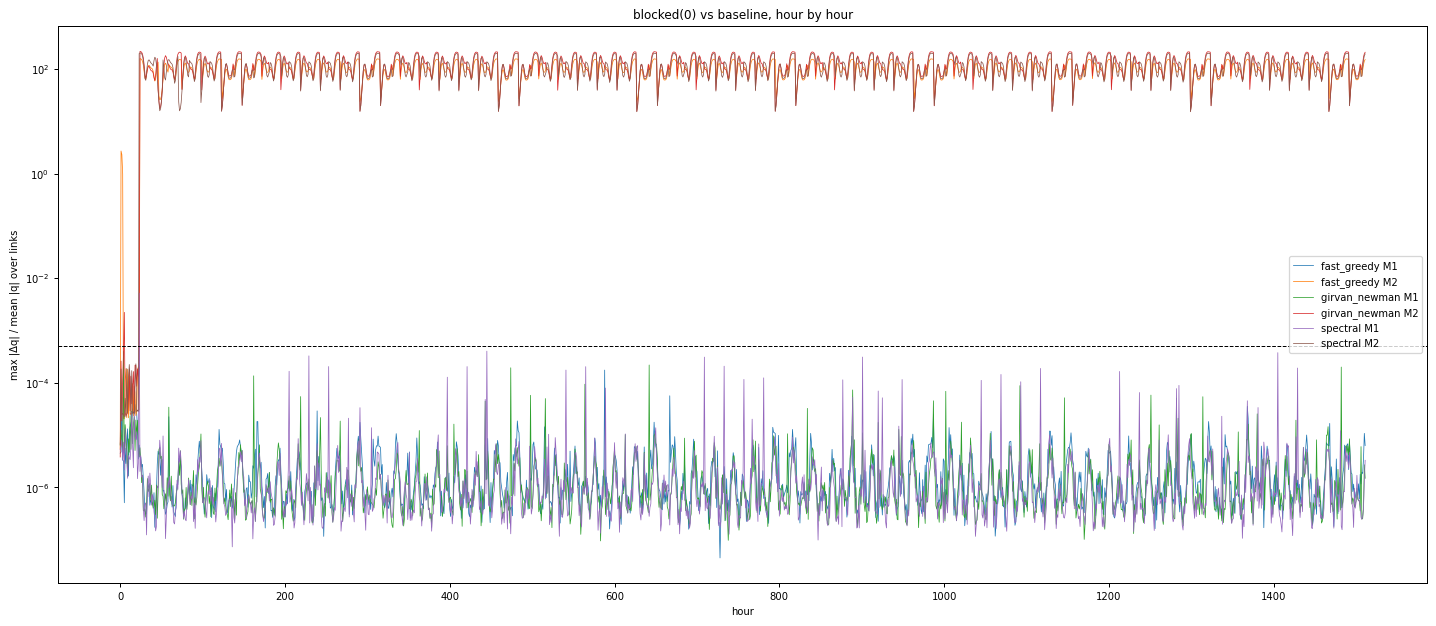

**Modes that pass every gate: none.** A mode that fails is not used below.

In [12]:
E2L, E2G = pd.concat(E2_LINK, ignore_index=True), pd.DataFrame(E2_GATE)
tp = TOPO.drop_duplicates("element").set_index("element")["topo"]
E2L["topo"] = E2L["element"].map(tp).fillna("other")
E2L["home"] = [PART[m]["home"].get(e) for m, e in zip(E2L["districting"], E2L["element"])]
E2L["own"] = E2L["home"] == E2L["k"]
E2L["storage"] = [PART[m]["storage"].get(e, np.nan) for m, e in zip(E2L["districting"], E2L["element"])]
E2L["scale"] = E2L["g_de0"].abs() + E2L["g_ie0"].abs()
E2L["sto_share0"] = E2L["g_ie0"].abs() / E2L["scale"].where(E2L["g_tot"].abs() >= EPS_MIN)
E2L["interaction"] = (E2L["g_de1"] - E2L["g_de0"]).abs() / E2L["scale"].where(E2L["g_tot"].abs() >= EPS_MIN)
E2L["pred_err"] = (E2L["g_sto_pred"] - E2L["g_ie0"]).abs() / E2L["scale"].where(E2L["g_tot"].abs() >= EPS_MIN)
E2L["g_dem_resid_pred"] = E2L["g_tot"] - E2L["g_sto_pred"]
E2L.to_parquet(OUT / "e2_link.parquet", index=False)
E2G.to_parquet(OUT / "e2_gate.parquet", index=False)

G2 = []
for mode in MODES:
    ga, gl = E2G[E2G["mode"] == mode], E2L[(E2L["mode"] == mode) & (E2L["topo"] == "branch")]
    va = ga[ga["gate"].str.startswith("a")]["max_rel"].max()
    vb = ga[ga["gate"].str.startswith("b")]["max_rel"].max()
    vc = gl[["g_ie0", "g_ie1"]].abs().max().max() if len(gl) else np.nan
    rl = pd.DataFrame([x for x in RUNLOG if x.get("section") == "E2" and x.get("mode") == mode])
    bad = int((~rl["completed"] | (rl["unbalanced_steps"] > 0)).sum()) if len(rl) else -1
    G2 += [{"mode": mode, "gate": "G-E2run every blocked run completed and converged", "value": f"{bad} failing",
            "passed": bad == 0},
           {"mode": mode, "gate": "G-E2h every hour has a head reference", "value": int(ga["ill_posed_hours"].max()),
            "passed": bool(ga["ill_posed_hours"].max() == 0)},
           {"mode": mode, "gate": "G-E2a blocked(0) reproduces the baseline", "value": f"{va:.1e}",
            "passed": bool(va <= GATE_E2_REL)},
           {"mode": mode, "gate": "G-E2b blocked(dose, dosed trajectory) reproduces the dosed run", "value": f"{vb:.1e}",
            "passed": bool(vb <= GATE_E2_REL)},
           {"mode": mode, "gate": "G-E2c no storage channel on branches", "value": f"{vc:.1e}",
            "passed": bool(np.isfinite(vc) and vc <= GATE_E2_BRANCH)}]
GT2 = pd.DataFrame(G2)
display(GT2)
display(Markdown("per run (worst link, hours above the gate)"))
display(E2G.sort_values("max_rel", ascending=False).head(15))
EH = pd.concat(E2_HOURLY, ignore_index=True)
bad_h = EH[EH["max_rel"] > GATE_E2_REL]
if len(bad_h):
    display(Markdown("**Where the twin departs** — hours above the gate: count per partition × mode × gate, "
                     "and the links worst at those hours"))
    display(bad_h.groupby(["districting", "mode", "gate"]).agg(hours=("hour", "nunique"),
                                                                 first_hour=("hour", "min")))
    display(bad_h.groupby(["districting", "mode", "worst"]).size().sort_values(ascending=False).head(15)
            .rename("hours worst").to_frame())
    fig, ax = plt.subplots(figsize=(16, 7))
    for (m, mode), q_ in EH[EH["gate"].str.startswith("a")].groupby(["districting", "mode"]):
        ax.semilogy(q_["hour"], q_["max_rel"].clip(1e-12), lw=0.6, label=f"{m} {mode}")
    ax.axhline(GATE_E2_REL, color="k", lw=0.8, ls="--")
    ax.set(xlabel="hour", ylabel="max |Δq| / mean |q| over links", title="blocked(0) vs baseline, hour by hour")
    ax.legend(); fig.tight_layout(); plt.show()
MODES_OK = [md for md in MODES if GT2[GT2["mode"] == md]["passed"].all()]
E2_OK = bool(MODES_OK)
display(Markdown(f"**Modes that pass every gate: {MODES_OK or 'none'}.** A mode that fails is not used below."))
if E2_OK:
    act = E2L[(E2L["g_tot"].abs() >= EPS_MIN) & E2L["mode"].isin(MODES_OK)]
    rows = []
    for (m, mode, tp_, sto, own), g in act.groupby(["districting", "mode", "topo", "storage", "own"], dropna=False):
        ok = g["g_sto_pred"].notna()
        nzs = g["g_ie0"].abs() > EPS_RESP[1]
        rows.append({"districting": m, "mode": mode, "topo": tp_, "storage class": sto, "own": own, "n": len(g),
                     "median storage share": g["sto_share0"].median(),
                     "median interaction": g["interaction"].median(), "q90 interaction": g["interaction"].quantile(0.9),
                     "Spearman pred vs exact storage": spear(g[ok]["g_sto_pred"], g[ok]["g_ie0"]),
                     "median |pred - exact| / scale": g[ok]["pred_err"].median(),
                     "sign agree pred (|g_ie|>3e-3)": float((np.sign(g[ok & nzs]["g_sto_pred"]) == np.sign(g[ok & nzs]["g_ie0"])).mean())
                     if (ok & nzs).any() else np.nan,
                     "Spearman resid demand vs exact demand": spear(g[ok]["g_dem_resid_pred"], g[ok]["g_de0"])})
    display(Markdown("**Channels** (links with $\\lvert g_{tot}\\rvert\\geq$ EPS_MIN). storage share $=\\lvert g_{ie0}\\rvert/(\\lvert g_{de0}\\rvert+\\lvert g_{ie0}\\rvert)$; "
                     "interaction $=\\lvert g_{de1}-g_{de0}\\rvert$ / same scale; the switch-fit prediction $\\sum_p b_{s,p}\\gamma_{p,k}$ "
                     "against the exact storage channel $g_{ie0}$, and the residual demand channel $g_{tot}-\\sum_p b\\gamma$ "
                     "against the exact demand channel $g_{de0}$"))
    E2S = pd.DataFrame(rows)
    E2S.to_parquet(OUT / "e2_summary.parquet", index=False)
    display(E2S.round(3))
    mm = act.pivot_table(index=["districting", "k", "delta", "element", "topo"], columns="mode",
                         values=["g_de0", "sto_share0"]).dropna()
    if len(MODES_OK) == 2 and len(mm):
        a_, b_ = MODES_OK
        mm.columns = [f"{v}_{md}" for v, md in mm.columns]
        mm["abs_d_share"] = (mm[f"sto_share0_{a_}"] - mm[f"sto_share0_{b_}"]).abs()
        display(Markdown(f"**{a_} vs {b_}** — does the way tanks are blocked change the split? (storage share difference, quantiles)"))
        display(mm.reset_index().groupby(["districting", "topo"])["abs_d_share"].quantile([0.5, 0.9]).unstack().round(3))
    fig, axes = plt.subplots(1, 3, figsize=(16, 7))
    for ax, (x, y, ttl) in zip(axes, (("g_ie0", "g_sto_pred", "switch-fit storage vs exact storage channel"),
                                      ("g_de0", "g_de1", "direct effect at baseline vs dosed mediators"),
                                      ("g_de0", "g_dem_resid_pred", "residual demand (g − Σbγ) vs exact demand"))):
        for mode, mk in zip(MODES_OK, ("o", "^")):
            for tp_, cc in (("branch", "#2e8b57"), ("source_bridge", "#444444"), ("loop", "#e08214")):
                q_ = act[(act["mode"] == mode) & (act["topo"] == tp_)]
                ax.scatter(q_[x], q_[y], s=5, alpha=0.35, color=cc, marker=mk, label=f"{tp_} {mode}")
        lim = np.nanpercentile(np.abs(act[[x, y]].to_numpy(float)), 99) if len(act) else 1
        ax.plot([-lim, lim], [-lim, lim], color="0.5", lw=0.8)
        ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel=x, ylabel=y, title=ttl)
    axes[0].legend(markerscale=3, fontsize=6)
    fig.tight_layout(); plt.show()

## Files

| file | one row per |
|---|---|
| `e0_world`, `e0_link`, `e0_tank_hourly`, `e0_pump` | world / world × link / world × tank × hour / world × pump |
| `e0c_link`, `e0c_tank`, `e0c_pump`, `e0c_gain` | partition × step × link / tank / pump; partition × district × output × link |
| `e4_gain`, `e4_linearity`, `e4_drive`, `e4_run`, `e4_tank`, `e4_branch`, `e4_vs_study` | partition × district × dose (× output) × link / pump / tank |
| `e2_link`, `e2_gate`, `e2_gate_hourly`, `e2_mediators`, `e2_summary` | partition × mode × district × dose × link / run / run × hour / mediator / group |

In [13]:
display(pd.DataFrame([{"file": f.name, "rows": len(pd.read_parquet(f)), "MB": round(f.stat().st_size / 1e6, 2)}
                      for f in sorted(OUT.glob("*.parquet"))]))
pd.DataFrame(RUNLOG).to_parquet(OUT / "runs.parquet", index=False)

,file,rows,MB
0,e0_link.parquet,7248,0.15
1,e0_pump.parquet,12,0.01
2,e0_tank_hourly.parquet,217728,0.92
3,e0_world.parquet,12,0.01
4,e0c_gain.parquet,14496,0.78
5,e0c_link.parquet,5436,0.19
6,e0c_pump.parquet,9,0.01
7,e0c_tank.parquet,27,0.00
8,e2_gate.parquet,54,0.01
9,e2_gate_hourly.parquet,81648,0.77
